# RetailPulse AI — Australian Retail Market & Location Decision Intelligence

An end-to-end decision intelligence project combining Australian household spending data with Melbourne pedestrian activity to identify market signals and priority locations for further commercial investigation.

Method: Raw data → quality audit → transformation → KPI analysis → signal generation → decision priorities → Tableau-ready outputs.

Important analytical boundary: Spending and pedestrian datasets are analysed separately and combined only at the decision-support step. The project does not claim that spending changes cause pedestrian changes or vice versa.


## 1. ABS Australia — Load and Data Quality Audit


In [1]:
import os

file_path = "data/raw/ABS Monthly Household Spending Indicator/5682002.Australia.xlsx"

print(os.path.exists(file_path))

True


Loading file

In [2]:
import pandas as pd

raw_aus = pd.read_excel(
    file_path,
    sheet_name="Data1",
    header=None
)

Loading the data into pandas without including the header

In [3]:
print(raw_aus.shape)
raw_aus.head(15)

(179, 91)


,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
0,NaN,Household spending ; Total (Household Spendin...,Household spending ; Food ; Australia ; Cur...,Household spending ; Alcoholic beverages and ...,Household spending ; Clothing and footwear ; ...,Household spending ; Furnishings and househol...,Household spending ; Health ; Australia ; C...,Household spending ; Transport ; Australia ;...,Household spending ; Recreation and culture ;...,"Household spending ; Hotels, cafes and restau...",...,Household spending - Through the year percenta...,Household spending - Through the year percenta...,Household spending - Through the year percenta...,Household spending - Through the year percenta...,Household spending - Through the year percenta...,Household spending - Through the year percenta...,Household spending - Through the year percenta...,Household spending - Through the year percenta...,Household spending - Through the year percenta...,Household spending - Through the year percenta...
1,Unit,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,...,Percent,Percent,Percent,Percent,Percent,Percent,Percent,Percent,Percent,Percent
2,Series Type,Original,Original,Original,Original,Original,Original,Original,Original,Original,...,Trend,Trend,Trend,Trend,Trend,Trend,Trend,Trend,Trend,Trend
3,Data Type,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,...,PERCENT,PERCENT,PERCENT,PERCENT,PERCENT,PERCENT,PERCENT,PERCENT,PERCENT,PERCENT
4,Frequency,Month,Month,Month,Month,Month,Month,Month,Month,Month,...,Month,Month,Month,Month,Month,Month,Month,Month,Month,Month
5,Collection Month,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
6,Series Start,2012-07-01 00:00:00,2012-07-01 00:00:00,2012-07-01 00:00:00,2012-07-01 00:00:00,2012-07-01 00:00:00,2012-07-01 00:00:00,2012-07-01 00:00:00,2012-07-01 00:00:00,2012-07-01 00:00:00,...,2012-07-01 00:00:00,2012-07-01 00:00:00,2012-07-01 00:00:00,2012-07-01 00:00:00,2012-07-01 00:00:00,2012-07-01 00:00:00,2012-07-01 00:00:00,2012-07-01 00:00:00,2012-07-01 00:00:00,2012-07-01 00:00:00
7,Series End,2026-07-01 00:00:00,2026-07-01 00:00:00,2026-07-01 00:00:00,2026-07-01 00:00:00,2026-07-01 00:00:00,2026-07-01 00:00:00,2026-07-01 00:00:00,2026-07-01 00:00:00,2026-07-01 00:00:00,...,2026-07-01 00:00:00,2026-07-01 00:00:00,2026-07-01 00:00:00,2026-07-01 00:00:00,2026-07-01 00:00:00,2026-07-01 00:00:00,2026-07-01 00:00:00,2026-07-01 00:00:00,2026-07-01 00:00:00,2026-07-01 00:00:00
8,No. Obs,169,169,169,169,169,169,169,169,169,...,169,169,169,169,169,169,169,169,169,169
9,Series ID,A130207496V,A130207592V,A130207514L,A130207328J,A130207418L,A130207424J,A130207598J,A130207334C,A130207346L,...,A130204044A,A130204140A,A130204062F,A130203876X,A130203966C,A130203972X,A130204146R,A130203882V,A130203894C,A130204236V


Checking dataset size and first rows

In [4]:
raw_aus.iloc[:12, :12]

,0,1,2,3,4,5,6,7,8,9,10,11
0,NaN,Household spending ; Total (Household Spendin...,Household spending ; Food ; Australia ; Cur...,Household spending ; Alcoholic beverages and ...,Household spending ; Clothing and footwear ; ...,Household spending ; Furnishings and househol...,Household spending ; Health ; Australia ; C...,Household spending ; Transport ; Australia ;...,Household spending ; Recreation and culture ;...,"Household spending ; Hotels, cafes and restau...",Household spending ; Miscellaneous goods and ...,Household spending - Percentage change from pr...
1,Unit,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,Percent
2,Series Type,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original
3,Data Type,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,PERCENT
4,Frequency,Month,Month,Month,Month,Month,Month,Month,Month,Month,Month,Month
5,Collection Month,1,1,1,1,1,1,1,1,1,1,1
6,Series Start,2012-07-01 00:00:00,2012-07-01 00:00:00,2012-07-01 00:00:00,2012-07-01 00:00:00,2012-07-01 00:00:00,2012-07-01 00:00:00,2012-07-01 00:00:00,2012-07-01 00:00:00,2012-07-01 00:00:00,2012-07-01 00:00:00,2012-07-01 00:00:00
7,Series End,2026-07-01 00:00:00,2026-07-01 00:00:00,2026-07-01 00:00:00,2026-07-01 00:00:00,2026-07-01 00:00:00,2026-07-01 00:00:00,2026-07-01 00:00:00,2026-07-01 00:00:00,2026-07-01 00:00:00,2026-07-01 00:00:00,2026-07-01 00:00:00
8,No. Obs,169,169,169,169,169,169,169,169,169,169,169
9,Series ID,A130207496V,A130207592V,A130207514L,A130207328J,A130207418L,A130207424J,A130207598J,A130207334C,A130207346L,A130207688L,A130207498X


Checking the first 12 rows and 12 columns for understanding.
I kept the raw column unnamed at first because it contained both metadata labels(Metadata labels are the fields that describe the dataset) and dates. Once I separated the actual monthly observations, I renamed that field to month so it had a clear analytical meaning.

In [5]:
for i in range(1, 11):
    print(i, raw_aus.iloc[0, i])

1 Household spending ;  Total (Household Spending Categories) ;  Australia ;  Current Price ;
2 Household spending ;  Food ;  Australia ;  Current Price ;
3 Household spending ;  Alcoholic beverages and tobacco ;  Australia ;  Current Price ;
4 Household spending ;  Clothing and footwear ;  Australia ;  Current Price ;
5 Household spending ;  Furnishings and household equipment ;  Australia ;  Current Price ;
6 Household spending ;  Health ;  Australia ;  Current Price ;
7 Household spending ;  Transport ;  Australia ;  Current Price ;
8 Household spending ;  Recreation and culture ;  Australia ;  Current Price ;
9 Household spending ;  Hotels, cafes and restaurants ;  Australia ;  Current Price ;
10 Household spending ;  Miscellaneous goods and services ;  Australia ;  Current Price ;


I checked the labels of the first 10 spending columns to understand which household spending category each column represents before deciding which ones to use in the analysis.

In [6]:
dates = pd.to_datetime(raw_aus.iloc[10:, 0], errors="coerce")

print("First date:", dates.min())
print("Last date:", dates.max())
print("Number of observations:", len(dates))
print("Unique months:", dates.nunique())
print("Missing dates:", dates.isna().sum())
print("Duplicate months:", dates.duplicated().sum())

First date: 2012-07-01 00:00:00
Last date: 2026-07-01 00:00:00
Number of observations: 169
Unique months: 169
Missing dates: 0
Duplicate months: 0


I checked the monthly date column starting from row 10, where the actual observations begins, to make sure the time series is complete and reliable. I confirmed the first and last dates, the total number of observations and checked for any missing or duplicate months.

In [7]:
expected_dates = pd.date_range(
    start=dates.min(),
    end=dates.max(),
    freq="MS"
)

missing_months = expected_dates.difference(dates)

print("Expected months:", len(expected_dates))
print("Missing months:", len(missing_months))
print(missing_months)

Expected months: 169
Missing months: 0
DatetimeIndex([], dtype='datetime64[us]', freq='MS')


This step is checking whether there are any gaps between the monthly dates. I created the full monthly date sequence from the first month to the last month and compared it with the dates available in the dataset. This confirmed that there are no missing months in the Australian spending data.

In [8]:
selected_cols = {
    1: "total_spending",
    4: "clothing_footwear",
    5: "furnishings_household",
    8: "recreation_culture",
    9: "hotels_cafes_restaurants",
    10: "misc_goods_services"
}

audit_aus = pd.DataFrame()

audit_aus["month"] = pd.to_datetime(
    raw_aus.iloc[10:, 0].values
)

for col_num, col_name in selected_cols.items():
    audit_aus[col_name] = pd.to_numeric(
        raw_aus.iloc[10:, col_num].values,
        errors="coerce"
    )

audit_aus.head()

,month,total_spending,clothing_footwear,furnishings_household,recreation_culture,hotels_cafes_restaurants,misc_goods_services
0,2012-07-01,43472.1,2365.7,3092.2,7501.4,5050.0,3964.7
1,2012-08-01,44537.9,2326.1,3142.4,7547.7,5293.0,4026.4
2,2012-09-01,43376.5,2364.9,3161.4,7138.9,5441.3,3952.5
3,2012-10-01,45158.5,2461.5,3266.0,7502.0,5111.0,4129.1
4,2012-11-01,45437.2,2661.0,3397.3,7636.0,4963.3,4204.0


Selecting important columns, creating an empty DataFrame to store the cleaned data, and creating the month column using the first column from row 10 onwards. Then it goes through each selected column one by one, takes the values from row 10 onwards, converts them into numeric format, and stores them in the new DataFrame using the clearer column names. If any value cannot be converted into a number, it is changed to NaN so it can be checked later.

In [9]:
audit_aus.info()

<class 'pandas.DataFrame'>
RangeIndex: 169 entries, 0 to 168
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   month                     169 non-null    datetime64[us]
 1   total_spending            169 non-null    float64       
 2   clothing_footwear         169 non-null    float64       
 3   furnishings_household     169 non-null    float64       
 4   recreation_culture        169 non-null    float64       
 5   hotels_cafes_restaurants  169 non-null    float64       
 6   misc_goods_services       169 non-null    float64       
dtypes: datetime64[us](1), float64(6)
memory usage: 9.4 KB


Final check on the data types and non-null counts in the audit table to confirm that the month column is stored as a date and all spending columns are numeric. I also confirmed that there are no missing values in these selected fields.

In [10]:
audit_aus.isna().sum()

month                       0
total_spending              0
clothing_footwear           0
furnishings_household       0
recreation_culture          0
hotels_cafes_restaurants    0
misc_goods_services         0
dtype: int64

Counts null values in every audit DataFrame.


In [11]:
for col in audit_aus.columns[1:]:
    print(
        col,
        "| min:", audit_aus[col].min(),
        "| max:", audit_aus[col].max(),
        "| missing:", audit_aus[col].isna().sum(),
        "| zero:", (audit_aus[col] == 0).sum(),
        "| negative:", (audit_aus[col] < 0).sum()
    )

total_spending | min: 39758.4 | max: 86202.8 | missing: 0 | zero: 0 | negative: 0
clothing_footwear | min: 1640.1 | max: 6206.6 | missing: 0 | zero: 0 | negative: 0
furnishings_household | min: 2802.9 | max: 6640.1 | missing: 0 | zero: 0 | negative: 0
recreation_culture | min: 6566.0 | max: 14927.2 | missing: 0 | zero: 0 | negative: 0
hotels_cafes_restaurants | min: 2838.8 | max: 11730.9 | missing: 0 | zero: 0 | negative: 0
misc_goods_services | min: 3167.2 | max: 7933.0 | missing: 0 | zero: 0 | negative: 0


I checked the minimum and maximum values for each selected spending column and looked for missing, unrealistic, zero or negative values. I excluded the first column because it contains the month/date field. This helped me identify whether there were any obvious data quality issues that needed further investigation.

## 2. ABS Victoria — Compatibility and Series Selection


In [12]:
import pandas as pd

vic_path = "data/raw/ABS Monthly Household Spending Indicator/5682004.Victoria.xlsx"

raw_vic = pd.read_excel(
    vic_path,
    sheet_name="Data1",
    header=None
)

print(raw_vic.shape)

(179, 127)


I loaded the Victoria Data1 worksheet in the same raw format as the Australia dataset so both files could be checked and prepared in a consistent way before comparison.

In [13]:
for i in range(1, 11):
    print(i, raw_vic.iloc[0, i])

1 Household spending ;  Total (Household Spending Categories) ;  Victoria ;  Current Price ;
2 Household spending ;  Goods ;  Victoria ;  Current Price ;
3 Household spending ;  Services ;  Victoria ;  Current Price ;
4 Household spending ;  Discretionary ;  Victoria ;  Current Price ;
5 Household spending ;  Non Discretionary ;  Victoria ;  Current Price ;
6 Household spending ;  Food ;  Victoria ;  Current Price ;
7 Household spending ;  Alcoholic beverages and tobacco ;  Victoria ;  Current Price ;
8 Household spending ;  Clothing and footwear ;  Victoria ;  Current Price ;
9 Household spending ;  Furnishings and household equipment ;  Victoria ;  Current Price ;
10 Household spending ;  Health ;  Victoria ;  Current Price ;


I checked the first 10 series labels in the Victoria dataset to understand how its spending categories are structured. This also showed that the Victoria file includes some additional aggregate categories such as Goods, Services and Discretionary spending.

In [14]:
aus_dates = pd.to_datetime(raw_aus.iloc[10:, 0])
vic_dates = pd.to_datetime(raw_vic.iloc[10:, 0])

print("Same number of months:", len(aus_dates) == len(vic_dates))
print("Same dates:", aus_dates.reset_index(drop=True).equals(
    vic_dates.reset_index(drop=True)
))

Same number of months: True
Same dates: True


I compared the Australia and Victoria date columns to make sure both datasets cover the same number of months and contain exactly the same dates. Both checks returned True, which confirmed that the two datasets are aligned in time and can be compared directly.

In [15]:
print("Australia unit:", raw_aus.iloc[1, 1])
print("Victoria unit :", raw_vic.iloc[1, 1])

print("Australia frequency:", raw_aus.iloc[4, 1])
print("Victoria frequency :", raw_vic.iloc[4, 1])

Australia unit: $ Millions
Victoria unit : $ Millions
Australia frequency: Month
Victoria frequency : Month


I checked that both datasets use the same unit and reporting frequency. Both Australia and Victoria are measured in $ Millions and reported monthly, which means they can be compared consistently later.

## 3. ABS Metadata-Driven Transformation


In [16]:
def build_series_metadata(raw_df, geography):

    rows = []

    for col in range(1, raw_df.shape[1]):

        label = raw_df.iloc[0, col]

        if pd.isna(label):
            continue

        parts = [p.strip() for p in str(label).split(";")]

        category = parts[1] if len(parts) > 1 else None

        rows.append({
            "column_number": col,
            "category": category,
            "geography": geography,
            "unit": raw_df.iloc[1, col],
            "series_type": raw_df.iloc[2, col],
            "data_type": raw_df.iloc[3, col],
            "frequency": raw_df.iloc[4, col],
            "series_id": raw_df.iloc[9, col],
            "full_label": label
        })

    return pd.DataFrame(rows)

It goes through every ABS series column, extracts the metadata stored in the top rows, and turns that information into one structured metadata table where each row represents one series.

Basically, converted the metadata that was stored vertically in the raw ABS sheet into structured columns, with one row describing each spending series.

In [17]:
aus_metadata = build_series_metadata(
    raw_aus,
    "Australia"
)

vic_metadata = build_series_metadata(
    raw_vic,
    "Victoria"
)

I applied the metadata function to both the Australia and Victoria datasets to create separate structured metadata tables. This makes it easier to compare the available series and filter the correct ones for analysis later.

In [18]:
aus_metadata.head(15)

,column_number,category,geography,unit,series_type,data_type,frequency,series_id,full_label
0,1,Total (Household Spending Categories),Australia,$ Millions,Original,FLOW,Month,A130207496V,Household spending ; Total (Household Spendin...
1,2,Food,Australia,$ Millions,Original,FLOW,Month,A130207592V,Household spending ; Food ; Australia ; Cur...
2,3,Alcoholic beverages and tobacco,Australia,$ Millions,Original,FLOW,Month,A130207514L,Household spending ; Alcoholic beverages and ...
3,4,Clothing and footwear,Australia,$ Millions,Original,FLOW,Month,A130207328J,Household spending ; Clothing and footwear ; ...
4,5,Furnishings and household equipment,Australia,$ Millions,Original,FLOW,Month,A130207418L,Household spending ; Furnishings and househol...
5,6,Health,Australia,$ Millions,Original,FLOW,Month,A130207424J,Household spending ; Health ; Australia ; C...
6,7,Transport,Australia,$ Millions,Original,FLOW,Month,A130207598J,Household spending ; Transport ; Australia ;...
7,8,Recreation and culture,Australia,$ Millions,Original,FLOW,Month,A130207334C,Household spending ; Recreation and culture ;...
8,9,"Hotels, cafes and restaurants",Australia,$ Millions,Original,FLOW,Month,A130207346L,"Household spending ; Hotels, cafes and restau..."
9,10,Miscellaneous goods and services,Australia,$ Millions,Original,FLOW,Month,A130207688L,Household spending ; Miscellaneous goods and ...


Displays the first Australia metadata records, to check data was extracted correctly.


In [19]:
vic_metadata.head(15)

,column_number,category,geography,unit,series_type,data_type,frequency,series_id,full_label
0,1,Total (Household Spending Categories),Victoria,$ Millions,Original,FLOW,Month,A130208264A,Household spending ; Total (Household Spendin...
1,2,Goods,Victoria,$ Millions,Original,FLOW,Month,A130208426F,Household spending ; Goods ; Victoria ; Cur...
2,3,Services,Victoria,$ Millions,Original,FLOW,Month,A130208288V,Household spending ; Services ; Victoria ; ...
3,4,Discretionary,Victoria,$ Millions,Original,FLOW,Month,A130208420T,Household spending ; Discretionary ; Victori...
4,5,Non Discretionary,Victoria,$ Millions,Original,FLOW,Month,A130208414W,Household spending ; Non Discretionary ; Vic...
5,6,Food,Victoria,$ Millions,Original,FLOW,Month,A130208360A,Household spending ; Food ; Victoria ; Curr...
6,7,Alcoholic beverages and tobacco,Victoria,$ Millions,Original,FLOW,Month,A130208282F,Household spending ; Alcoholic beverages and ...
7,8,Clothing and footwear,Victoria,$ Millions,Original,FLOW,Month,A130208096A,Household spending ; Clothing and footwear ; ...
8,9,Furnishings and household equipment,Victoria,$ Millions,Original,FLOW,Month,A130208186F,Household spending ; Furnishings and househol...
9,10,Health,Victoria,$ Millions,Original,FLOW,Month,A130208192A,Household spending ; Health ; Victoria ; Cu...


Displays the first Victoria metadata records, extraction works correctly for Victoria.


In [20]:
aus_current_price = aus_metadata[
    (aus_metadata["unit"] == "$ Millions") &
    (aus_metadata["series_type"] == "Original") &
    (aus_metadata["data_type"] == "FLOW") &
    (aus_metadata["frequency"] == "Month")
].copy()


vic_current_price = vic_metadata[
    (vic_metadata["unit"] == "$ Millions") &
    (vic_metadata["series_type"] == "Original") &
    (vic_metadata["data_type"] == "FLOW") &
    (vic_metadata["frequency"] == "Month")
].copy()

Keep only the Australian series where all four conditions are true.

Filtered both metadata tables to keep only the monthly Original spending series measured in $ Millions and stored as FLOW data. This gives me one consistent version of the spending measures for both Australia and Victoria and avoids mixing different series types.

Why this matters: the ABS workbook can contain different versions of similar measures, such as Trend or percentage series. This filter makes sure you are using one consistent type of spending series for both Australia and Victoria.

In [21]:
print("Australia:", len(aus_current_price))
print(aus_current_price[
    ["column_number", "category", "series_id"]
].to_string(index=False))

print("\nVictoria:", len(vic_current_price))
print(vic_current_price[
    ["column_number", "category", "series_id"]
].to_string(index=False))

Australia: 10
 column_number                              category   series_id
             1 Total (Household Spending Categories) A130207496V
             2                                  Food A130207592V
             3       Alcoholic beverages and tobacco A130207514L
             4                 Clothing and footwear A130207328J
             5   Furnishings and household equipment A130207418L
             6                                Health A130207424J
             7                             Transport A130207598J
             8                Recreation and culture A130207334C
             9         Hotels, cafes and restaurants A130207346L
            10      Miscellaneous goods and services A130207688L

Victoria: 14
 column_number                              category   series_id
             1 Total (Household Spending Categories) A130208264A
             2                                 Goods A130208426F
             3                              Services A13020828

Checked the filtered results to confirm which spending series were selected for Australia and Victoria. Australia has 10 categories, while Victoria has 14 because it also includes Goods, Services, Discretionary and Non Discretionary aggregates. I also kept the column number and Series ID so I could verify exactly which ABS series were being used.

In [22]:
common_categories = sorted(
    set(aus_current_price["category"]) &
    set(vic_current_price["category"])
)

print("Common categories:", len(common_categories))

for category in common_categories:
    print(category)

Common categories: 10
Alcoholic beverages and tobacco
Clothing and footwear
Food
Furnishings and household equipment
Health
Hotels, cafes and restaurants
Miscellaneous goods and services
Recreation and culture
Total (Household Spending Categories)
Transport


Categories present in both datasets: Identified the spending categories that are available in both the Australia and Victoria datasets. This confirmed that there are 10 common categories, which are the ones I can use for direct comparison between the two geographies.

In [23]:
def transform_abs_to_long(raw_df, metadata_df, geography):
    
    selected = metadata_df[
        (metadata_df["unit"] == "$ Millions") &
        (metadata_df["series_type"] == "Original") &
        (metadata_df["data_type"] == "FLOW") &
        (metadata_df["frequency"] == "Month")
    ].copy()
    
    rows = []
    
    dates = pd.to_datetime(raw_df.iloc[10:, 0].values)
    
    for _, series in selected.iterrows():
        
        col = series["column_number"]
        category = series["category"]
        series_id = series["series_id"]
        
        values = pd.to_numeric(
            raw_df.iloc[10:, col].values,
            errors="coerce"
        )
        
        temp = pd.DataFrame({
            "month": dates,
            "geography": geography,
            "category": category,
            "spending_millions": values,
            "series_id": series_id
        })
        
        rows.append(temp)
    
    return pd.concat(rows, ignore_index=True)

I converted the separate spending category columns into a long format, where the category names are stored in one column and all spending values are stored in one spending_millions column.

In [24]:
aus_long = transform_abs_to_long(
    raw_aus,
    aus_metadata,
    "Australia"
)

vic_long = transform_abs_to_long(
    raw_vic,
    vic_metadata,
    "Victoria"
)

Applied the long-format transformation to both the Australia and Victoria datasets so they follow the same structure. This makes it easier to compare the two datasets and combine them later.

In [25]:
print(aus_long.shape)
print(vic_long.shape)

aus_long.head()

(1690, 5)
(2366, 5)


,month,geography,category,spending_millions,series_id
0,2012-07-01,Australia,Total (Household Spending Categories),43472.1,A130207496V
1,2012-08-01,Australia,Total (Household Spending Categories),44537.9,A130207496V
2,2012-09-01,Australia,Total (Household Spending Categories),43376.5,A130207496V
3,2012-10-01,Australia,Total (Household Spending Categories),45158.5,A130207496V
4,2012-11-01,Australia,Total (Household Spending Categories),45437.2,A130207496V


Checked the size of the transformed Australia and Victoria datasets and previewed the Australia result to make sure the expected months and categories were still present after reshaping the data.

In [26]:
spending_long = pd.concat(
    [aus_long, vic_long],
    ignore_index=True
)

Combined the Australia and Victoria long format datasets into one DataFrame. The geography column keeps track of which rows belong to Australia or Victoria, which makes later comparisons easier.

In [27]:
print(spending_long.shape)
spending_long.head()

(4056, 5)


,month,geography,category,spending_millions,series_id
0,2012-07-01,Australia,Total (Household Spending Categories),43472.1,A130207496V
1,2012-08-01,Australia,Total (Household Spending Categories),44537.9,A130207496V
2,2012-09-01,Australia,Total (Household Spending Categories),43376.5,A130207496V
3,2012-10-01,Australia,Total (Household Spending Categories),45158.5,A130207496V
4,2012-11-01,Australia,Total (Household Spending Categories),45437.2,A130207496V


Checked the shape and first few rows of the combined dataset to make sure Australia and Victoria were stacked correctly and the final table had the expected columns and structure.

In [28]:
spending_long.info()

<class 'pandas.DataFrame'>
RangeIndex: 4056 entries, 0 to 4055
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   month              4056 non-null   datetime64[us]
 1   geography          4056 non-null   str           
 2   category           4056 non-null   str           
 3   spending_millions  4056 non-null   float64       
 4   series_id          4056 non-null   str           
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 158.6 KB


I checked the data types and non null counts in the combined spending dataset to make sure the month column is stored as a date, the spending values are numeric, and there are no missing values before moving into KPI calculations.

In [29]:
print(spending_long.isna().sum())

month                0
geography            0
category             0
spending_millions    0
series_id            0
dtype: int64


This step is checking specifically for missing values in the combined spending dataset.

In [30]:
print(
    spending_long.groupby("geography")["category"].nunique()
)

geography
Australia    10
Victoria     14
Name: category, dtype: int64


This step is checking how many unique spending categories each geography still has after all the transformation and combining.

In [31]:
print(
    spending_long.groupby("geography")["month"].nunique()
)

geography
Australia    169
Victoria     169
Name: month, dtype: int64


This is another post transformation validation check but this time for the dates.

In [32]:
output_path = "data/processed/abs_spending_long.csv"

spending_long.to_csv(
    output_path,
    index=False
)

This step is saving the cleaned and combined ABS dataset as a new CSV file.

## 4. Melbourne Pedestrian Data — Quality Audit


In [33]:
import pandas as pd

ped_path = "data/raw/City of Melbourne Pedestrian Counting System/pedestrian-counting-system-monthly-counts-per-hour.csv"

ped = pd.read_csv(ped_path)

print(ped.shape)
ped.head()

(1622619, 9)


,ID,Location_ID,Sensing_Date,HourDay,Direction_1,Direction_2,Total_of_Directions,Sensor_Name,Location
0,41120260921,41,2026-09-21,1,27,43,70,Swa31,"-37.81668634, 144.96689733"
1,6120260921,6,2026-09-21,1,0,3,3,FliS_T,"-37.81907439, 144.96557866"
2,31220260921,31,2026-09-21,2,5,2,7,Lyg161_T,"-37.80169681, 144.96658911"
3,49220260921,49,2026-09-21,2,15,12,27,Eli501_T,"-37.80730068, 144.95956055"
4,5220260921,5,2026-09-21,2,17,19,36,PriNW_T,"-37.81874249, 144.96787656"


Loading the Melbourne pedestrian dataset and checking what it looks like before we start cleaning/analysing it.

In [34]:
print(ped.columns.tolist())

['ID', 'Location_ID', 'Sensing_Date', 'HourDay', 'Direction_1', 'Direction_2', 'Total_of_Directions', 'Sensor_Name', 'Location']


Inspecting all pedestrian column names.

In [35]:
ped.info()

<class 'pandas.DataFrame'>
RangeIndex: 1622619 entries, 0 to 1622618
Data columns (total 9 columns):
 #   Column               Non-Null Count    Dtype
---  ------               --------------    -----
 0   ID                   1622619 non-null  int64
 1   Location_ID          1622619 non-null  int64
 2   Sensing_Date         1622619 non-null  str  
 3   HourDay              1622619 non-null  int64
 4   Direction_1          1622619 non-null  int64
 5   Direction_2          1622619 non-null  int64
 6   Total_of_Directions  1622619 non-null  int64
 7   Sensor_Name          1600351 non-null  str  
 8   Location             1600351 non-null  str  
dtypes: int64(6), str(3)
memory usage: 111.4 MB


Displaying data types, non null counts and memory usage, checking which fields are numeric, which are strings and where missing values may already exist.

In [36]:
ped.isna().sum()

ID                         0
Location_ID                0
Sensing_Date               0
HourDay                    0
Direction_1                0
Direction_2                0
Total_of_Directions        0
Sensor_Name            22268
Location               22268
dtype: int64

Check pedestrian missing values.

In [37]:
print("Duplicate rows:", ped.duplicated().sum())

Duplicate rows: 0


Checking for duplicate pedestrian rows

In [38]:
ped["Sensing_Date"] = pd.to_datetime(
    ped["Sensing_Date"],
    errors="coerce"
)

print("First date:", ped["Sensing_Date"].min())
print("Last date:", ped["Sensing_Date"].max())
print("Invalid dates:", ped["Sensing_Date"].isna().sum())

First date: 2024-09-22 00:00:00
Last date: 2026-09-21 00:00:00
Invalid dates: 0


I converted Sensing_Date(date in which pedestrian count was recorded) into datetime format and checked the first date, last date and any invalid dates. This confirmed the pedestrian dataset covers the period from September 2024 to September 2026 and contains no invalid date values.

In [39]:
print("Unique Location_IDs:", ped["Location_ID"].nunique())
print("Missing Location_IDs:", ped["Location_ID"].isna().sum())

Unique Location_IDs: 103
Missing Location_IDs: 0


Counts unique sensor/location IDs and missing IDs.

In [40]:
print(sorted(ped["HourDay"].dropna().unique()))

[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]


Checked the HourDay column to confirm that all 24 hours, from 0 to 23, are represented in the pedestrian dataset. This confirms the dataset includes observations across the full day, although I check sensor-level coverage separately later.

In [41]:
ped["Total_of_Directions"] = pd.to_numeric(
    ped["Total_of_Directions"],
    errors="coerce"
)

print("Missing totals:", ped["Total_of_Directions"].isna().sum())
print("Negative totals:", (ped["Total_of_Directions"] < 0).sum())
print("Zero totals:", (ped["Total_of_Directions"] == 0).sum())
print("Minimum:", ped["Total_of_Directions"].min())
print("Maximum:", ped["Total_of_Directions"].max())

Missing totals: 0
Negative totals: 0
Zero totals: 143
Minimum: 0
Maximum: 11113


Converted Total_of_Directions into numeric format and checked for missing, negative and zero values, as well as the minimum and maximum counts. This is important because Total_of_Directions is the main footfall measure used later in the location analysis. The results showed no missing or negative values, while the zero counts may still be valid observations.

In [42]:
print("Missing Sensor_Name:", ped["Sensor_Name"].isna().sum())
print("Missing Location:", ped["Location"].isna().sum())

Missing Sensor_Name: 22268
Missing Location: 22268


I checked how many pedestrian records are missing the sensor name and location information. This showed that 22,268 rows are missing both fields, which made me understand how much of the count data may need additional sensor metadata later.

In [43]:
missing_meta = ped[
    ped["Sensor_Name"].isna() |
    ped["Location"].isna()
]

print("Rows with missing metadata:", len(missing_meta))
print("Unique Location_IDs affected:", missing_meta["Location_ID"].nunique())

print(
    missing_meta["Location_ID"]
    .value_counts()
    .sort_index()
)

Rows with missing metadata: 22268
Unique Location_IDs affected: 3
Location_ID
28     9974
65      531
78    11763
Name: count, dtype: int64


The missing metadata problem is concentrated in Location IDs 28, 65 and 78.

I filtered the rows with missing sensor name or location information and checked which Location_IDs were affected. This showed that all 22,268 missing-metadata rows come from only three sensor IDs, so the issue is concentrated rather than spread across the whole dataset.

In [44]:
ped["direction_sum"] = (
    ped["Direction_1"] +
    ped["Direction_2"]
)

mismatch_count = (
    ped["direction_sum"] != ped["Total_of_Directions"]
).sum()

print("Direction total mismatches:", mismatch_count)

Direction total mismatches: 0


Added the two directional pedestrian counts together and compared the result with Total_of_Directions. This confirmed that the reported total matches the sum of both directions for every row, with no mismatches. (Direction_1 and Direction_2 are the two opposite pedestrian travel directions recorded by each sensor.)

In [45]:
zero_counts = ped[
    ped["Total_of_Directions"] == 0
]

print("Zero-count rows:", len(zero_counts))
print("Sensors with zero counts:", zero_counts["Location_ID"].nunique())

zero_counts[
    ["Sensing_Date", "HourDay", "Location_ID", "Sensor_Name"]
].head(20)

Zero-count rows: 143
Sensors with zero counts: 3


,Sensing_Date,HourDay,Location_ID,Sensor_Name
234763,2026-06-08,0,188,RMIT51_T
721576,2025-11-04,3,27,Vic_T
958292,2025-07-23,3,25,MCEC_T
958404,2025-07-23,10,25,MCEC_T
958763,2025-07-23,8,25,MCEC_T
958899,2025-07-23,9,25,MCEC_T
959366,2025-07-23,11,25,MCEC_T
959463,2025-07-23,7,25,MCEC_T
959931,2025-07-23,4,25,MCEC_T
960246,2025-07-23,5,25,MCEC_T


Checked the zero-footfall rows to see which sensors, dates and hours they were linked to. This helped me identify whether the zeros looked isolated or concentrated enough to need further investigation.

The zero counts were concentrated in only three sensors rather than being widespread across the dataset. Most of the zero observations appeared around one sensor and time period, so I treated them as something to monitor rather than automatically removing them as errors.

## 5. Sensor Reference Audit and Pedestrian Enrichment


In [46]:
sensor_path = "data/raw/City of Melbourne Pedestrian Counting System/pedestrian-counting-system-sensor-locations.csv"

sensors = pd.read_csv(sensor_path)

print(sensors.shape)
print(sensors.columns.tolist())

sensors.head()

(134, 12)
['Location_ID', 'Sensor_Description', 'Sensor_Name', 'Installation_Date', 'Note', 'Location_Type', 'Status', 'Direction_1', 'Direction_2', 'Latitude', 'Longitude', 'Location']


,Location_ID,Sensor_Description,Sensor_Name,Installation_Date,Note,Location_Type,Status,Direction_1,Direction_2,Latitude,Longitude,Location
0,3,Melbourne Central,Swa295_T,2009-03-25,NaN,Outdoor,A,North,South,-37.811015,144.964295,"-37.81101524, 144.96429485"
1,5,Princes Bridge,PriNW_T,2009-03-26,Replace with: 00:6e:02:01:9e:54,Outdoor,A,North,South,-37.818742,144.967877,"-37.81874249, 144.96787656"
2,9,Southern Cross Station,Col700_T,2009-03-23,NaN,Outdoor,A,East,West,-37.819830,144.951026,"-37.81982992, 144.95102555"
3,11,Docklands Waterfront City Building Side,WatCit_T,2009-01-20,Device has been replaced with new sensor on 22...,Outdoor,A,East,West,-37.815667,144.939744,"-37.81566651, 144.93974366"
4,12,New Quay,NewQ_T,2009-01-21,NaN,Outdoor,A,East,West,-37.814580,144.942924,"-37.81457988, 144.94292398"


Loaded the separate sensor reference dataset to get additional information about each pedestrian sensor, including its description, location, coordinates, status and walking directions. I can later join this information back to the pedestrian count data using Location_ID.

Found that the sensor reference dataset contains the additional descriptive information needed to understand each sensor properly, including the location description, coordinates, status and actual walking directions. It also uses Location_ID, which means I can join this information back to the pedestrian count data.

In [47]:
sensors.info()

<class 'pandas.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Location_ID         134 non-null    int64  
 1   Sensor_Description  134 non-null    str    
 2   Sensor_Name         134 non-null    str    
 3   Installation_Date   131 non-null    str    
 4   Note                38 non-null     str    
 5   Location_Type       134 non-null    str    
 6   Status              134 non-null    str    
 7   Direction_1         100 non-null    str    
 8   Direction_2         100 non-null    str    
 9   Latitude            134 non-null    float64
 10  Longitude           134 non-null    float64
 11  Location            134 non-null    str    
dtypes: float64(2), int64(1), str(9)
memory usage: 12.7 KB


Checked the sensor reference table to see the data types and how complete each field is. Understanding which sensor details could be reliably used later when joining the reference data with the pedestrian counts.

In [48]:
sensors.isna().sum()

Location_ID            0
Sensor_Description     0
Sensor_Name            0
Installation_Date      3
Note                  96
Location_Type          0
Status                 0
Direction_1           34
Direction_2           34
Latitude               0
Longitude              0
Location               0
dtype: int64

Counting null values for each sensor field.

In [49]:
print("Unique Location_IDs:", sensors["Location_ID"].nunique())
print("Duplicate Location_IDs:", sensors["Location_ID"].duplicated().sum())

Unique Location_IDs: 134
Duplicate Location_IDs: 0


Checked whether Location_ID is unique in the sensor reference table and confirmed that all 134 sensor IDs are unique with no duplicates. This means I can safely use Location_ID to join the sensor details to the pedestrian count data.

In [50]:
ped_ids = set(ped["Location_ID"].unique())
sensor_ids = set(sensors["Location_ID"].unique())

print("IDs in pedestrian data:", len(ped_ids))
print("IDs in sensor file:", len(sensor_ids))

print("Pedestrian IDs missing from sensor reference:")
print(sorted(ped_ids - sensor_ids))

print("Sensor IDs with no pedestrian records:")
print(sorted(sensor_ids - ped_ids))

IDs in pedestrian data: 103
IDs in sensor file: 134
Pedestrian IDs missing from sensor reference:
[np.int64(28), np.int64(65), np.int64(78)]
Sensor IDs with no pedestrian records:
[np.int64(80), np.int64(81), np.int64(82), np.int64(83), np.int64(89), np.int64(90), np.int64(91), np.int64(92), np.int64(93), np.int64(94), np.int64(95), np.int64(96), np.int64(99), np.int64(102), np.int64(103), np.int64(104), np.int64(105), np.int64(106), np.int64(116), np.int64(144), np.int64(145), np.int64(146), np.int64(147), np.int64(148), np.int64(149), np.int64(150), np.int64(151), np.int64(152), np.int64(153), np.int64(154), np.int64(155), np.int64(158), np.int64(159), np.int64(160)]


Compared the `Location_ID`s in the pedestrian count data with the sensor reference table. I found that three sensor IDs in the count data, 28, 65 and 78, do not have a matching record in the reference file. I also found some sensors in the reference table that do not have pedestrian records in this dataset. I decided to keep all pedestrian count records and use a left join so the available sensor details can be added without removing the unmatched count data.

In [51]:
ped_enriched = ped.merge(
    sensors,
    on="Location_ID",
    how="left",
    suffixes=("_count", "_sensor")
)

print(ped_enriched.shape)

(1622619, 21)


Joined the pedestrian count data with the sensor reference table using Location_ID. I used a left join so all pedestrian records were kept, including the unmatched sensor IDs 28, 65 and 78. The sensor reference fields were added where a match was available.

In [52]:
ped_enriched.head()

,ID,Location_ID,Sensing_Date,HourDay,Direction_1_count,Direction_2_count,Total_of_Directions,Sensor_Name_count,Location_count,direction_sum,...,Sensor_Name_sensor,Installation_Date,Note,Location_Type,Status,Direction_1_sensor,Direction_2_sensor,Latitude,Longitude,Location_sensor
0,41120260921,41,2026-09-21,1,27,43,70,Swa31,"-37.81668634, 144.96689733",70,...,Swa31,2017-06-29,NaN,Outdoor,A,North,South,-37.816686,144.966897,"-37.81668634, 144.96689733"
1,6120260921,6,2026-09-21,1,0,3,3,FliS_T,"-37.81907439, 144.96557866",3,...,FliS_T,2009-03-25,Upgraded on 8/09/21,Outdoor,A,North,South,-37.819074,144.965579,"-37.81907439, 144.96557866"
2,31220260921,31,2026-09-21,2,5,2,7,Lyg161_T,"-37.80169681, 144.96658911",7,...,Lyg161_T,2013-10-10,"Pushbox Upgrade, 25/07/2023",Outdoor,A,North,South,-37.801697,144.966589,"-37.80169681, 144.96658911"
3,49220260921,49,2026-09-21,2,15,12,27,Eli501_T,"-37.80730068, 144.95956055",27,...,Eli501_T,NaN,501 Elizabeth Street upgrade 23/06/2026,Outdoor,A,East,West,-37.807301,144.959561,"-37.80730068, 144.95956055"
4,5220260921,5,2026-09-21,2,17,19,36,PriNW_T,"-37.81874249, 144.96787656",36,...,PriNW_T,2009-03-26,Replace with: 00:6e:02:01:9e:54,Outdoor,A,North,South,-37.818742,144.967877,"-37.81874249, 144.96787656"


Previewed the new pedestrian dataset to make sure the sensor reference details were added correctly after the join. I could see the original pedestrian count fields alongside the sensor information such as status, directions and coordinates.

In [53]:
ped_enriched["metadata_match_flag"] = (
    ped_enriched["Sensor_Name_sensor"]
    .notna()
    .map({
        True: "Matched",
        False: "Unmatched"
    })
)

Created a flag to show whether each pedestrian record successfully matched with the sensor reference table. This makes the unmatched records easy to identify later instead of letting the missing metadata go unnoticed.

In [54]:
ped_enriched["metadata_match_flag"].value_counts()

metadata_match_flag
Matched      1600351
Unmatched      22268
Name: count, dtype: int64

Counted the matched and unmatched pedestrian records after the join. Most rows matched successfully, while 22,268 remained unmatched, which is consistent with the missing metadata issue identified earlier.

In [55]:
ped_enriched.loc[
    ped_enriched["metadata_match_flag"] == "Unmatched",
    "Location_ID"
].value_counts()

Location_ID
78    11763
28     9974
65      531
Name: count, dtype: int64

Checked which Location_IDs were still unmatched after the join and confirmed that they were the same three IDs identified earlier: 28, 65 and 78.

## 6. Pedestrian Monthly Transformation


In [56]:
ped_enriched["month"] = (
    ped_enriched["Sensing_Date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

Created a month field from Sensing_Date by converting each observation to the first day of its month. This gives me one consistent monthly key that I can use to aggregate the hourly pedestrian data later.

In [57]:
ped_enriched["day_of_week"] = (
    ped_enriched["Sensing_Date"]
    .dt.day_name()
)

Created a day_of_week field from Sensing_Date so each pedestrian record is labelled with the day it occurred. This is to analyse how pedestrian activity differs across the week.

In [58]:
ped_enriched["day_type"] = (
    ped_enriched["Sensing_Date"]
    .dt.dayofweek
    .apply(lambda x: "Weekend" if x >= 5 else "Weekday")
)

Created a day_type field that groups Monday to Friday as Weekday and Saturday and Sunday as Weekend. This makes it easier to compare weekday and weekend pedestrian activity later.

In [59]:
ped_enriched[
    [
        "Sensing_Date",
        "month",
        "day_of_week",
        "day_type",
        "Location_ID",
        "Total_of_Directions",
        "metadata_match_flag"
    ]
].head(10)

,Sensing_Date,month,day_of_week,day_type,Location_ID,Total_of_Directions,metadata_match_flag
0,2026-09-21,2026-09-01,Monday,Weekday,41,70,Matched
1,2026-09-21,2026-09-01,Monday,Weekday,6,3,Matched
2,2026-09-21,2026-09-01,Monday,Weekday,31,7,Matched
3,2026-09-21,2026-09-01,Monday,Weekday,49,27,Matched
4,2026-09-21,2026-09-01,Monday,Weekday,5,36,Matched
5,2026-09-21,2026-09-01,Monday,Weekday,86,2,Matched
6,2026-09-21,2026-09-01,Monday,Weekday,24,41,Matched
7,2026-09-21,2026-09-01,Monday,Weekday,67,20,Matched
8,2026-09-21,2026-09-01,Monday,Weekday,9,4,Matched
9,2026-09-21,2026-09-01,Monday,Weekday,39,1,Matched


Previewed the new time fields together to make sure the month, day of week and weekday/weekend labels were created correctly and still aligned with the original pedestrian records.

In [60]:
monthly_footfall = (
    ped_enriched
    .groupby(
        [
            "month",
            "Location_ID",
            "metadata_match_flag"
        ],
        dropna=False
    )
    .agg(
        monthly_footfall=("Total_of_Directions", "sum"),
        avg_hourly_footfall=("Total_of_Directions", "mean"),
        observation_count=("Total_of_Directions", "count")
    )
    .reset_index()
)

Grouped the hourly pedestrian records by month and Location_ID and created monthly footfall, average hourly footfall and observation count for each sensor. This reduces the large hourly dataset into a smaller monthly location-level table that is easier to use for the later analysis.

In [61]:
print(monthly_footfall.shape)
monthly_footfall.head()

(2458, 6)


,month,Location_ID,metadata_match_flag,monthly_footfall,avg_hourly_footfall,observation_count
0,2024-09-01,1,Matched,197477,918.497674,215
1,2024-09-01,2,Matched,120504,557.888889,216
2,2024-09-01,3,Matched,235612,1090.796296,216
3,2024-09-01,4,Matched,255924,1184.833333,216
4,2024-09-01,5,Matched,209005,967.615741,216


Checked the size and first few rows of the monthly footfall table to make sure the hourly records were grouped correctly into one row for each month and sensor location.

In [62]:
location_lookup = sensors[
    [
        "Location_ID",
        "Sensor_Description",
        "Sensor_Name",
        "Latitude",
        "Longitude",
        "Location_Type",
        "Status"
    ]
].copy()

Created a smaller location reference table by keeping only the sensor fields I need for reporting and mapping. This makes the next join cleaner and avoids carrying unnecessary columns through the rest of the analysis.

In [63]:
monthly_footfall = monthly_footfall.merge(
    location_lookup,
    on="Location_ID",
    how="left"
)

Joined the smaller location reference table to the monthly footfall data using Location_ID. This added readable sensor details and coordinates to each monthly record while still keeping unmatched historical sensor IDs.

In [64]:
daytype_footfall = (
    ped_enriched
    .groupby(
        ["month", "Location_ID", "day_type"],
        dropna=False
    )["Total_of_Directions"]
    .sum()
    .unstack(fill_value=0)
    .reset_index()
)

Grouped the pedestrian counts by month, location and day type, then separated Weekday and Weekend into their own columns. This gives me the totals I need later to compare weekday and weekend activity and calculate weekend share.

In [65]:
daytype_footfall = daytype_footfall.rename(
    columns={
        "Weekday": "weekday_footfall",
        "Weekend": "weekend_footfall"
    }
)

Renamed the Weekday and Weekend columns to weekday_footfall and weekend_footfall so it is clear that they contain pedestrian totals and can be used more easily in later calculations and Tableau.

In [66]:
monthly_footfall = monthly_footfall.merge(
    daytype_footfall,
    on=["month", "Location_ID"],
    how="left"
)

Merged the weekday and weekend totals back into the main monthly footfall table using month and Location_ID. This keeps all the location level monthly measures together in one dataset for the later KPI calculations.

In [67]:
monthly_footfall["weekend_share_pct"] = (
    monthly_footfall["weekend_footfall"]
    / monthly_footfall["monthly_footfall"]
    * 100
)

Calculated weekend_share_pct to measure what percentage of each location’s monthly pedestrian traffic occurred on weekends. This helps me understand whether a location is more weekend-oriented or mainly driven by weekday activity.

In [68]:
print(monthly_footfall.shape)
print(monthly_footfall.columns.tolist())

(2458, 15)
['month', 'Location_ID', 'metadata_match_flag', 'monthly_footfall', 'avg_hourly_footfall', 'observation_count', 'Sensor_Description', 'Sensor_Name', 'Latitude', 'Longitude', 'Location_Type', 'Status', 'weekday_footfall', 'weekend_footfall', 'weekend_share_pct']


Checked the final size and column names of the monthly footfall dataset to confirm that all the location details and calculated fields were included before moving on to the final validation and KPI analysis.

In [69]:
duplicate_month_location = monthly_footfall.duplicated(
    subset=["month", "Location_ID"]
).sum()

print("Duplicate month-location rows:", duplicate_month_location)

Duplicate month-location rows: 0


Checked for duplicate month and Location_ID combinations and confirmed there were none. This means the dataset has the intended structure of one row per location for each month.

In [70]:
print(
    monthly_footfall.loc[
        monthly_footfall["metadata_match_flag"] == "Unmatched",
        "Location_ID"
    ].unique()
)

[28 65 78]


Checked that the unmatched sensor IDs were still present after the monthly aggregation and joins. This confirmed that Location IDs 28, 65 and 78 were preserved and no pedestrian records were accidentally removed.

In [71]:
monthly_footfall.isna().sum()

month                   0
Location_ID             0
metadata_match_flag     0
monthly_footfall        0
avg_hourly_footfall     0
observation_count       0
Sensor_Description     35
Sensor_Name            35
Latitude               35
Longitude              35
Location_Type          35
Status                 35
weekday_footfall        0
weekend_footfall        0
weekend_share_pct       0
dtype: int64

Checked the final monthly dataset for missing values. All core KPI fields were complete, while the remaining nulls were only in the descriptive sensor fields for the unmatched sensor IDs 28, 65 and 78.

In [72]:
original_total = ped_enriched["Total_of_Directions"].sum()

monthly_total = monthly_footfall["monthly_footfall"].sum()

print("Original total:", original_total)
print("Monthly total:", monthly_total)
print("Match:", original_total == monthly_total)

Original total: 640355803
Monthly total: 640355803
Match: True


Compared the total pedestrian count before and after the monthly aggregation and confirmed that both totals matched exactly. This shows that no pedestrian counts were lost or duplicated during the aggregation.

In [73]:
daytype_mismatch = (
    monthly_footfall["weekday_footfall"]
    + monthly_footfall["weekend_footfall"]
    != monthly_footfall["monthly_footfall"]
).sum()

print("Weekday/weekend mismatches:", daytype_mismatch)

Weekday/weekend mismatches: 0


Checked that weekday_footfall plus weekend_footfall matched monthly_footfall for every month and location. There were no mismatches, which confirms the weekday/weekend split was calculated correctly.

In [74]:
monthly_footfall["is_partial_month"] = monthly_footfall["month"].isin(
    [
        pd.Timestamp("2024-09-01"),
        pd.Timestamp("2026-09-01")
    ]
)

The partial months could distort monthly comparisons because they do not contain a full month of pedestrian activity. Flagged them first and later excluded them from the KPI analysis so they would not affect growth calculations.

In [75]:
output_path = "data\processed\pedestrian_monthly_location.csv"

monthly_footfall.to_csv(
    output_path,
    index=False
)

Saved the monthly location level pedestrian dataset as a CSV file in the processed data folder so I could reuse the cleaned and validated version later for KPI calculations, Tableau and the decision intelligence steps.

## 7. Spending KPI and Benchmark Analysis


In [76]:
abs_spending = pd.read_csv(
    "data\processed\abs_spending_long.csv",
    parse_dates=["month"]
)

abs_spending.head()

,month,geography,category,spending_millions,series_id
0,2012-07-01,Australia,Total (Household Spending Categories),43472.1,A130207496V
1,2012-08-01,Australia,Total (Household Spending Categories),44537.9,A130207496V
2,2012-09-01,Australia,Total (Household Spending Categories),43376.5,A130207496V
3,2012-10-01,Australia,Total (Household Spending Categories),45158.5,A130207496V
4,2012-11-01,Australia,Total (Household Spending Categories),45437.2,A130207496V


Loaded the processed ABS spending dataset back into pandas and made sure the month column was read as a date. From this point, using the cleaned analysis ready file instead of going back to the raw Excel workbooks.

In [77]:
abs_spending = abs_spending.sort_values(
    ["geography", "category", "month"]
).reset_index(drop=True)

Sorted the spending data by geography, category and month so that each spending series is in chronological order. This is important before calculating time based measures such as monthly and yearly growth rates.

In [78]:
abs_spending["mom_growth_pct"] = (
    abs_spending
    .groupby(["geography", "category"])["spending_millions"]
    .pct_change(fill_method=None)
    * 100
)

Calculated month-on-month spending growth for each geography and category by comparing each month with the previous month. This helps me identify short-term increases or decreases in spending while keeping each spending series separate.

In [79]:
abs_spending["yoy_growth_pct"] = (
    abs_spending
    .groupby(["geography", "category"])["spending_millions"]
    .pct_change(periods=12, fill_method=None)
    * 100
)

This step calculates the year-on-year (YoY) percentage change in spending for each geography and category separately. Calculated year-on-year spending growth for each geography and category by comparing each month with the same month in the previous year. This helps identify longer-term spending growth while reducing the effect of normal seasonal patterns.

In [80]:
abs_spending["spending_3m_avg"] = (
    abs_spending
    .groupby(["geography", "category"])["spending_millions"]
    .transform(
        lambda x: x.rolling(
            window=3,
            min_periods=3
        ).mean()
    )
)

Calculated a rolling three-month average for each geography and spending category. This helps smooth short-term monthly fluctuations and makes the underlying spending trend easier to identify.

In [81]:
abs_spending[
    (abs_spending["category"] ==
     "Furnishings and household equipment") &
    (abs_spending["geography"] == "Victoria")
][
    [
        "month",
        "spending_millions",
        "mom_growth_pct",
        "yoy_growth_pct",
        "spending_3m_avg"
    ]
].tail(15)

,month,spending_millions,mom_growth_pct,yoy_growth_pct,spending_3m_avg
2520,2025-05-01,1203.1,5.981325,2.829060,1171.400000
2521,2025-06-01,1259.5,4.687890,2.640372,1199.266667
2522,2025-07-01,1171.3,-7.002779,4.617721,1211.300000
2523,2025-08-01,1201.1,2.544182,1.401435,1210.633333
2524,2025-09-01,1229.8,2.389476,3.859471,1200.733333
2525,2025-10-01,1358.8,10.489510,4.290429,1263.233333
2526,2025-11-01,1582.4,16.455696,6.637914,1390.333333
2527,2025-12-01,1598.5,1.017442,2.956331,1513.233333
2528,2026-01-01,1239.1,-22.483578,4.618372,1473.333333
2529,2026-02-01,1094.4,-11.677831,3.646179,1310.666667


Reviewed a recent sample of Victorian furnishings spending together with the MoM growth, YoY growth and three month average. This helped me manually check that the new KPI calculations were behaving as expected before using them across the full dataset.

In [82]:
common_categories = sorted(
    set(
        abs_spending.loc[
            abs_spending["geography"] == "Australia",
            "category"
        ]
    )
    &
    set(
        abs_spending.loc[
            abs_spending["geography"] == "Victoria",
            "category"
        ]
    )
)

print("Common categories:", len(common_categories))
print(common_categories)

Common categories: 10
['Alcoholic beverages and tobacco', 'Clothing and footwear', 'Food', 'Furnishings and household equipment', 'Health', 'Hotels, cafes and restaurants', 'Miscellaneous goods and services', 'Recreation and culture', 'Total (Household Spending Categories)', 'Transport']


Identified the spending categories that are available in both the Australia and Victoria datasets. This gives me the 10 categories that can be used for direct comparison between the two geographies.

(One small thing to remember: Total (Household Spending Categories) is included in these 10 common categories, but later for category ranking, should still exclude Total because it is an overall aggregate rather than an individual spending category)

In [83]:
comparison_data = abs_spending[
    abs_spending["category"].isin(common_categories)
].copy()

Filtered the spending dataset to keep only the categories that are available for both Australia and Victoria. This gives me a comparable dataset for the later geography-level analysis.

In [84]:
aus_compare = (
    comparison_data[
        comparison_data["geography"] == "Australia"
    ][
        [
            "month",
            "category",
            "spending_millions",
            "mom_growth_pct",
            "yoy_growth_pct",
            "spending_3m_avg"
        ]
    ]
    .rename(
        columns={
            "spending_millions": "aus_spending_millions",
            "mom_growth_pct": "aus_mom_growth_pct",
            "yoy_growth_pct": "aus_yoy_growth_pct",
            "spending_3m_avg": "aus_spending_3m_avg"
        }
    )
)

Created a separate Australia benchmark table using the common spending categories and renamed the KPI columns with an aus_ prefix. This makes it clear which values belong to Australia when I later combine them with the Victoria results.

In [85]:
vic_compare = (
    comparison_data[
        comparison_data["geography"] == "Victoria"
    ][
        [
            "month",
            "category",
            "spending_millions",
            "mom_growth_pct",
            "yoy_growth_pct",
            "spending_3m_avg"
        ]
    ]
    .rename(
        columns={
            "spending_millions": "vic_spending_millions",
            "mom_growth_pct": "vic_mom_growth_pct",
            "yoy_growth_pct": "vic_yoy_growth_pct",
            "spending_3m_avg": "vic_spending_3m_avg"
        }
    )
)

Created a separate Victoria comparison table using the common spending categories and renamed the KPI columns with a vic_ prefix. This prepares the Victorian values for a direct comparison with the Australian benchmark.

In [86]:
spending_comparison = vic_compare.merge(
    aus_compare,
    on=["month", "category"],
    how="inner"
)

spending_comparison.head()

,month,category,vic_spending_millions,vic_mom_growth_pct,vic_yoy_growth_pct,vic_spending_3m_avg,aus_spending_millions,aus_mom_growth_pct,aus_yoy_growth_pct,aus_spending_3m_avg
0,2012-07-01,Alcoholic beverages and tobacco,557.8,NaN,NaN,NaN,2450.2,NaN,NaN,NaN
1,2012-08-01,Alcoholic beverages and tobacco,577.1,3.460022,NaN,NaN,2526.5,3.114032,NaN,NaN
2,2012-09-01,Alcoholic beverages and tobacco,576.5,-0.103968,NaN,570.466667,2519.5,-0.277063,NaN,2498.733333
3,2012-10-01,Alcoholic beverages and tobacco,604.2,4.804857,NaN,585.933333,2630.8,4.417543,NaN,2558.933333
4,2012-11-01,Alcoholic beverages and tobacco,613.1,1.473022,NaN,597.933333,2659.5,1.090923,NaN,2603.266667


Merged the Victoria and Australia benchmark tables using month and category so each row contains the Victorian and Australian values for the same spending category and time period. I used an inner join because this table is only for records that are directly comparable across both geographies.

In [87]:
spending_comparison["vic_vs_aus_yoy_gap"] = (
    spending_comparison["vic_yoy_growth_pct"]
    - spending_comparison["aus_yoy_growth_pct"]
)

Calculated the difference between Victoria’s YoY growth and Australia’s YoY growth for each category and month. A positive gap means Victoria is growing faster than the national benchmark, while a negative gap means it is growing more slowly.

In [88]:
spending_comparison[
    spending_comparison["category"]
    == "Furnishings and household equipment"
][
    [
        "month",
        "vic_spending_millions",
        "vic_yoy_growth_pct",
        "aus_spending_millions",
        "aus_yoy_growth_pct",
        "vic_vs_aus_yoy_gap"
    ]
].tail(12)

,month,vic_spending_millions,vic_yoy_growth_pct,aus_spending_millions,aus_yoy_growth_pct,vic_vs_aus_yoy_gap
664,2025-08-01,1201.1,1.401435,5110.3,2.571153,-1.169718
665,2025-09-01,1229.8,3.859471,5239.2,4.426860,-0.567389
666,2025-10-01,1358.8,4.290429,5725.1,6.154046,-1.863617
667,2025-11-01,1582.4,6.637914,6640.1,8.436352,-1.798438
668,2025-12-01,1598.5,2.956331,6636.9,4.257057,-1.300726
669,2026-01-01,1239.1,4.618372,5245.2,5.253441,-0.635069
670,2026-02-01,1094.4,3.646179,4613.3,3.774604,-0.128425
671,2026-03-01,1227.2,4.362616,5182.7,5.847153,-1.484537
672,2026-04-01,1188.4,4.686399,5012.0,5.671516,-0.985117
673,2026-05-01,1247.2,3.665531,5308.3,5.144000,-1.478470


Reviewed the recent furnishings results for Victoria and Australia side by side to check that the benchmark gap was calculated correctly. The results also showed that Victoria’s YoY growth was slightly below the national benchmark in most of the recent months.

In [89]:
latest_month = spending_comparison["month"].max()

latest_spending = spending_comparison[
    (spending_comparison["month"] == latest_month) &
    (
        spending_comparison["category"]
        != "Total (Household Spending Categories)"
    )
].copy()

latest_spending[
    [
        "category",
        "vic_yoy_growth_pct",
        "aus_yoy_growth_pct",
        "vic_vs_aus_yoy_gap"
    ]
].sort_values(
    "vic_yoy_growth_pct",
    ascending=False
)

,category,vic_yoy_growth_pct,aus_yoy_growth_pct,vic_vs_aus_yoy_gap
1351,Recreation and culture,9.049828,10.806999,-1.757171
1182,Miscellaneous goods and services,8.055309,8.237862,-0.182553
1689,Transport,7.649538,8.713208,-1.063669
337,Clothing and footwear,6.695887,6.451776,0.244111
506,Food,6.503128,6.538103,-0.034975
1013,"Hotels, cafes and restaurants",5.805358,7.267732,-1.462374
675,Furnishings and household equipment,4.516349,5.267973,-0.751623
844,Health,3.651966,4.573567,-0.921602
168,Alcoholic beverages and tobacco,-4.786115,3.743853,-8.529968


Created the latest spending snapshot by keeping only the most recent month and excluding the overall household-spending total. This gives me a like-for-like category view that I can use to rank current Victorian spending performance and generate market signals.

In [90]:
latest_spending["vic_growth_rank"] = (
    latest_spending["vic_yoy_growth_pct"]
    .rank(
        ascending=False,
        method="dense"
    )
    .astype(int)
)

Ranked the latest Victorian spending categories from highest to lowest YoY growth. This helps me quickly identify which categories are currently showing the strongest and weakest growth.

In [91]:
def spending_trend_flag(yoy_growth):
    
    if yoy_growth >= 5:
        return "Strong Growth"
    
    elif yoy_growth >= 2:
        return "Moderate Growth"
    
    elif yoy_growth > -2:
        return "Stable"
    
    else:
        return "Decline"

Created a simple set of rules to classify YoY spending growth as Strong Growth, Moderate Growth, Stable or Decline. This makes the numeric KPI results easier to interpret and use later in the decision layer.

In [92]:
latest_spending["spending_trend_flag"] = (
    latest_spending["vic_yoy_growth_pct"]
    .apply(spending_trend_flag)
)

Applied the trend classification function to the latest Victorian YoY growth values so each spending category has a simple business friendly label such as Strong Growth, Moderate Growth, Stable or Decline.

In [93]:
def benchmark_flag(gap):

    if gap >= 1:
        return "Outperforming Australia"

    elif gap <= -1:
        return "Underperforming Australia"

    else:
        return "In Line with Australia"

Created a benchmark flag to show whether Victoria is outperforming, in line with or underperforming Australia based on the YoY growth gap. This helps separate Victoria’s own growth trend from its performance relative to the national benchmark.

In [94]:
latest_spending["benchmark_flag"] = (
    latest_spending["vic_vs_aus_yoy_gap"]
    .apply(benchmark_flag)
)

Applied the benchmark classification to each category using the Victoria vs Australia YoY growth gap. This adds national context to the Victorian result by showing whether each category is outperforming, in line with or underperforming Australia.

In [95]:
latest_spending[
    [
        "category",
        "vic_yoy_growth_pct",
        "aus_yoy_growth_pct",
        "vic_vs_aus_yoy_gap",
        "vic_growth_rank",
        "spending_trend_flag",
        "benchmark_flag"
    ]
].sort_values("vic_growth_rank")

,category,vic_yoy_growth_pct,aus_yoy_growth_pct,vic_vs_aus_yoy_gap,vic_growth_rank,spending_trend_flag,benchmark_flag
1351,Recreation and culture,9.049828,10.806999,-1.757171,1,Strong Growth,Underperforming Australia
1182,Miscellaneous goods and services,8.055309,8.237862,-0.182553,2,Strong Growth,In Line with Australia
1689,Transport,7.649538,8.713208,-1.063669,3,Strong Growth,Underperforming Australia
337,Clothing and footwear,6.695887,6.451776,0.244111,4,Strong Growth,In Line with Australia
506,Food,6.503128,6.538103,-0.034975,5,Strong Growth,In Line with Australia
1013,"Hotels, cafes and restaurants",5.805358,7.267732,-1.462374,6,Strong Growth,Underperforming Australia
675,Furnishings and household equipment,4.516349,5.267973,-0.751623,7,Moderate Growth,In Line with Australia
844,Health,3.651966,4.573567,-0.921602,8,Moderate Growth,In Line with Australia
168,Alcoholic beverages and tobacco,-4.786115,3.743853,-8.529968,9,Decline,Underperforming Australia


This cell is a final inspection of the spending signal logic. Reviewed the growth rank, trend flag and Australia benchmark flag together to make sure the two signals were being interpreted correctly. This confirmed that a category can show strong growth in Victoria while still underperforming Australia if national growth is even stronger.

## 8. Pedestrian KPI and Coverage-Validated Growth Analysis


In [96]:
ped_monthly = pd.read_csv(
    "data\processed\pedestrian_monthly_location.csv",
    parse_dates=["month"]
)

ped_monthly.head()

,month,Location_ID,metadata_match_flag,monthly_footfall,avg_hourly_footfall,observation_count,Sensor_Description,Sensor_Name,Latitude,Longitude,Location_Type,Status,weekday_footfall,weekend_footfall,weekend_share_pct,is_partial_month
0,2024-09-01,1,Matched,197477,918.497674,215,Bourke Street Mall (North),Bou292_T,-37.813494,144.965153,Outdoor,A,133368,64109,32.464034,True
1,2024-09-01,2,Matched,120504,557.888889,216,Bourke Street Mall (South),Bou283_T,-37.813807,144.965167,Outdoor,A,84096,36408,30.213105,True
2,2024-09-01,3,Matched,235612,1090.796296,216,Melbourne Central,Swa295_T,-37.811015,144.964295,Outdoor,A,158015,77597,32.934231,True
3,2024-09-01,4,Matched,255924,1184.833333,216,Town Hall (West),Swa123_T,-37.814880,144.966088,Outdoor,A,171364,84560,33.041059,True
4,2024-09-01,5,Matched,209005,967.615741,216,Princes Bridge,PriNW_T,-37.818742,144.967877,Outdoor,A,136950,72055,34.475252,True


Loaded the processed monthly pedestrian dataset back into pandas and made sure the month column was read as a date. From this point, I use the cleaned location level dataset for the footfall KPI analysis.

In [97]:
ped_analysis = ped_monthly[
    ped_monthly["is_partial_month"] == False
].copy()

Excluded the partial months from the pedestrian analysis so incomplete monthly totals would not distort the KPI and growth calculations. The original processed data is still preserved but ped_analysis only contains complete months.

In [98]:
ped_analysis = ped_analysis.sort_values(
    ["Location_ID", "month"]
).reset_index(drop=True)

Sorted the pedestrian data by Location_ID and month so each location’s records are in chronological order. This prepares the data for time-based calculations such as monthly growth, yearly growth and rolling averages.

In [99]:
ped_mom = ped_analysis[
    [
        "month",
        "Location_ID",
        "monthly_footfall"
    ]
].copy()

previous_month = ped_mom.copy()

previous_month["month"] = (
    previous_month["month"]
    + pd.DateOffset(months=1)
)

previous_month = previous_month.rename(
    columns={
        "monthly_footfall": "previous_month_footfall"
    }
)

ped_analysis = ped_analysis.merge(
    previous_month[
        [
            "month",
            "Location_ID",
            "previous_month_footfall"
        ]
    ],
    on=["month", "Location_ID"],
    how="left"
)

ped_analysis["mom_footfall_growth_pct"] = (
    (
        ped_analysis["monthly_footfall"]
        - ped_analysis["previous_month_footfall"]
    )
    / ped_analysis["previous_month_footfall"]
    * 100
)

Matched each location’s monthly footfall with the exact previous calendar month and then calculated the percentage change. I used an explicit month based join rather than relying only on the previous row so missing months would not create misleading MoM comparisons.

In [100]:
ped_analysis[
    [
        "month",
        "Location_ID",
        "monthly_footfall",
        "previous_month_footfall",
        "mom_footfall_growth_pct"
    ]
].head(20)

,month,Location_ID,monthly_footfall,previous_month_footfall,mom_footfall_growth_pct
0,2024-10-01,1,757139,NaN,NaN
1,2024-11-01,1,837574,757139.0,10.623545
2,2024-12-01,1,1063048,837574.0,26.919890
3,2025-01-01,1,745185,1063048.0,-29.901096
4,2025-02-01,1,642561,745185.0,-13.771614
5,2025-03-01,1,755156,642561.0,17.522850
6,2025-04-01,1,732304,755156.0,-3.026130
7,2025-05-01,1,693445,732304.0,-5.306403
8,2025-06-01,1,653145,693445.0,-5.811564
9,2025-07-01,1,731372,653145.0,11.976973


Reviewed the MoM calculation for individual locations to confirm that each month was matched with the exact previous calendar month. Where the previous month was missing, the growth value remained blank instead of comparing against an older month. I also noticed some extreme changes where observation coverage was low, which I validate separately later.

In [101]:
ped_analysis["footfall_3m_avg"] = (
    ped_analysis
    .groupby("Location_ID")["monthly_footfall"]
    .transform(
        lambda x: x.rolling(
            window=3,
            min_periods=3
        ).mean()
    )
)

Calculated a rolling three month average of footfall for each location to smooth short-term fluctuations and make the broader pedestrian trend easier to see.

In [102]:
location_month_counts = (
    ped_analysis
    .groupby("Location_ID")["month"]
    .nunique()
    .sort_values()
)

location_month_counts.head(20)

Location_ID
65      1
187    11
188    11
28     14
185    15
184    15
78     17
1      17
182    17
180    18
181    18
124    21
179    21
108    22
5      23
6      23
20     23
21     23
24     23
23     23
Name: month, dtype: int64

Counted how many unique months of data were available for each location to check whether all sensors had a complete monthly history. The results showed that some locations have fewer months than others, so I need to be careful with YoY comparisons and cannot assume every sensor has continuous coverage.

In [103]:
location_month_counts.describe()

count    103.000000
mean      21.990291
std        3.197717
min        1.000000
25%       23.000000
50%       23.000000
75%       23.000000
max       23.000000
Name: month, dtype: float64

This summarised the number of months available for each location to understand how common incomplete sensor histories were. Most locations had the full 23 months of complete data, while a smaller number of sensors had shorter histories.

In [104]:
ped_analysis.groupby("Location_ID")["month"].agg(
    ["min", "max", "count"]
).head(20)

,min,max,count
Location_ID,,,
1,2024-10-01,2026-08-01,17
2,2024-10-01,2026-08-01,23
3,2024-10-01,2026-08-01,23
4,2024-10-01,2026-08-01,23
5,2024-10-01,2026-08-01,23
6,2024-10-01,2026-08-01,23
8,2024-10-01,2026-08-01,23
9,2024-10-01,2026-08-01,23
10,2024-10-01,2026-08-01,23


Checked the first month, last month and number of records available for each location. This helped me distinguish between sensors with complete monthly coverage and sensors that span the same period but have missing months in between.

In [105]:
ped_yoy = ped_analysis[
    [
        "month",
        "Location_ID",
        "monthly_footfall"
    ]
].copy()

previous_year = ped_yoy.copy()

previous_year["month"] = (
    previous_year["month"] + pd.DateOffset(years=1)
)

previous_year = previous_year.rename(
    columns={
        "monthly_footfall": "previous_year_footfall"
    }
)

ped_analysis = ped_analysis.merge(
    previous_year[
        [
            "month",
            "Location_ID",
            "previous_year_footfall"
        ]
    ],
    on=["month", "Location_ID"],
    how="left"
)

Matched each location with its exact same month from the previous year by shifting the historical records forward by one year and joining them back by month and Location_ID. This avoids incorrect YoY comparisons when a sensor has missing months.

In [106]:
ped_analysis["yoy_footfall_growth_pct"] = (
    (
        ped_analysis["monthly_footfall"]
        - ped_analysis["previous_year_footfall"]
    )
    / ped_analysis["previous_year_footfall"]
    * 100
)

Calculated YoY footfall growth using the explicitly matched previous-year value for each location. This ensures the comparison is based on the same calendar month and leaves the result blank when a valid prior-year match is not available.

In [107]:
print(
    ped_analysis["yoy_footfall_growth_pct"]
    .notna()
    .value_counts()
)

yoy_footfall_growth_pct
False    1223
True     1042
Name: count, dtype: int64


Counted how many rows had a valid YoY footfall result. This showed that 1,042 rows could be compared with the same month in the previous year, while 1,223 rows did not have a valid prior year match.

In [108]:
ped_analysis[
    ped_analysis["Sensor_Description"]
    == "Melbourne Central"
][
    [
        "month",
        "monthly_footfall",
        "previous_year_footfall",
        "yoy_footfall_growth_pct"
    ]
]

,month,monthly_footfall,previous_year_footfall,yoy_footfall_growth_pct
40,2024-10-01,736499,NaN,NaN
41,2024-11-01,721423,NaN,NaN
42,2024-12-01,805878,NaN,NaN
43,2025-01-01,691670,NaN,NaN
44,2025-02-01,647237,NaN,NaN
45,2025-03-01,817605,NaN,NaN
46,2025-04-01,809415,NaN,NaN
47,2025-05-01,749701,NaN,NaN
48,2025-06-01,695689,NaN,NaN
49,2025-07-01,806426,NaN,NaN


Reviewed Melbourne Central as a sample location to manually check the YoY calculation. The prior year values matched the same calendar month correctly, which confirmed that the date matching logic was working as intended. The NaN values here are because there is not yet a full year of historical data available, which is expected.

In [109]:
ped_analysis["expected_hours"] = (
    ped_analysis["month"].dt.days_in_month * 24
)

Calculated the number of hourly observations expected for each month based on the number of days in that month. Used this as a benchmark to check how complete each sensor-month is before trusting its KPI results.

In [110]:
ped_analysis["coverage_pct"] = (
    ped_analysis["observation_count"]
    / ped_analysis["expected_hours"]
    * 100
)

Calculated the percentage of expected hourly observations that were actually available for each sensor month. This helps me identify months where low footfall may be caused by missing sensor data rather than a genuine drop in pedestrian activity.

In [111]:
ped_analysis["coverage_pct"].describe()

count    2265.000000
mean       94.162055
std        11.812535
min         2.083333
25%        94.489247
50%        99.596774
75%       100.000000
max       100.000000
Name: coverage_pct, dtype: float64

Summarised the monthly sensor coverage to understand how complete the pedestrian data was overall. Most sensor-months had very high coverage, but a small number had very low coverage, so I needed a quality threshold before trusting the growth calculations.

In [112]:
ped_analysis[
    [
        "month",
        "Location_ID",
        "Sensor_Description",
        "observation_count",
        "expected_hours",
        "coverage_pct"
    ]
].sort_values("coverage_pct").head(20)

,month,Location_ID,Sensor_Description,observation_count,expected_hours,coverage_pct
14,2026-06-01,1,Bourke Street Mall (North),15,720,2.083333
2205,2025-06-01,185,197 Elizabeth Street,61,720,8.472222
2190,2025-06-01,184,124 Elizabeth Street,62,720,8.611111
2155,2025-03-01,181,368 Elizabeth Street,135,744,18.145161
1635,2024-12-01,124,Birrarung Marr East - Batman Ave Bridge Entry,163,744,21.908602
1542,2026-07-01,108,William St - Little Lonsdale St (West),187,744,25.134409
1653,2026-06-01,124,Birrarung Marr East - Batman Ave Bridge Entry,182,720,25.277778
1654,2026-07-01,124,Birrarung Marr East - Batman Ave Bridge Entry,194,744,26.075269
1652,2026-05-01,124,Birrarung Marr East - Batman Ave Bridge Entry,202,744,27.150538
1655,2026-08-01,124,Birrarung Marr East - Batman Ave Bridge Entry,203,744,27.284946


Inspected the sensor-months with the lowest data coverage to identify where missing hourly observations could make the footfall results unreliable. Some records had extremely low coverage, including months with less than 10% of expected observations, so these need to be treated carefully in later comparisons.

In [113]:
previous_year_coverage = ped_analysis[
    [
        "month",
        "Location_ID",
        "coverage_pct"
    ]
].copy()

previous_year_coverage["month"] = (
    previous_year_coverage["month"] + pd.DateOffset(years=1)
)

previous_year_coverage = previous_year_coverage.rename(
    columns={
        "coverage_pct": "previous_year_coverage_pct"
    }
)

Created a prior year coverage field by shifting each location’s monthly coverage forward by one year. This allows me to check whether both the current month and the same month in the previous year had enough data before trusting the YoY growth result.

In [114]:
ped_analysis = ped_analysis.merge(
    previous_year_coverage[
        [
            "month",
            "Location_ID",
            "previous_year_coverage_pct"
        ]
    ],
    on=["month", "Location_ID"],
    how="left"
)

Merged the prior year coverage values back into the pedestrian analysis table so each YoY comparison includes both the current month and previous year coverage. This lets me check the quality of both periods before treating the growth result as valid.

In [115]:
ped_analysis["valid_yoy_comparison"] = (
    (ped_analysis["coverage_pct"] >= 90) &
    (ped_analysis["previous_year_coverage_pct"] >= 90) &
    (ped_analysis["previous_year_footfall"].notna())
)

Created a validity flag for YoY comparisons by requiring at least 90% coverage in both the current month and the same month in the previous year, as well as an available prior-year footfall value. This ensures I only use growth rates based on sufficiently complete data.

In [116]:
ped_analysis["validated_yoy_footfall_growth_pct"] = (
    ped_analysis["yoy_footfall_growth_pct"]
    .where(ped_analysis["valid_yoy_comparison"])
)

Created a validated YoY growth field that only keeps growth rates when the comparison passes the coverage and data-availability checks. Unreliable comparisons are left blank so they are not used in later rankings or decision signals.

In [117]:
ped_analysis["valid_yoy_comparison"].value_counts()

valid_yoy_comparison
False    1447
True      818
Name: count, dtype: int64

Counted how many pedestrian records passed the YoY validation rule. This showed that 818 comparisons had sufficient current and prior year coverage, while the remaining rows were excluded from validated growth because they did not meet the quality requirements.

In [118]:
latest_ped_month = ped_analysis["month"].max()

latest_locations = ped_analysis[
    (ped_analysis["month"] == latest_ped_month) &
    (ped_analysis["valid_yoy_comparison"])
].copy()

Created the latest location snapshot by keeping only the most recent month and locations with a valid YoY comparison. This ensures the location rankings and signals are based only on reliable growth measurements.

In [119]:
latest_locations[
    [
        "Location_ID",
        "Sensor_Description",
        "monthly_footfall",
        "coverage_pct",
        "previous_year_footfall",
        "previous_year_coverage_pct",
        "validated_yoy_footfall_growth_pct",
        "weekend_share_pct"
    ]
].sort_values(
    "validated_yoy_footfall_growth_pct",
    ascending=False
).head(20)

,Location_ID,Sensor_Description,monthly_footfall,coverage_pct,previous_year_footfall,previous_year_coverage_pct,validated_yoy_footfall_growth_pct,weekend_share_pct
1134,63,231 Bourke St,351623,99.865591,274805.0,99.327957,27.953640,36.545107
1977,143,"Mounted on Toilet - Spencer Street, Batman Park",227928,100.000000,188129.0,100.000000,21.155165,43.289109
789,45,Little Collins St-Swanston St (East),643499,100.000000,533816.0,99.865591,20.546967,36.902777
973,53,Collins Street (North),457819,99.865591,393336.0,99.596774,16.393872,30.526038
904,50,Faraday St-Lygon St (West),180880,94.086022,155848.0,97.983871,16.061804,40.399713
1931,141,Awning of Nationwide Parking 474 Flinders Street,139615,100.000000,122538.0,100.000000,13.936085,37.907102
1451,85,Macaulay Rd (North),71472,90.725806,64059.0,91.129032,11.572144,32.671536
292,17,Collins Place (South),301666,99.865591,271094.0,100.000000,11.277269,16.067770
2023,162,iHub 489 Elizabeth Street,417526,100.000000,378498.0,100.000000,10.311283,39.869373
1365,77,Harbour Esplanade (West) - Pedestrian path,146071,98.252688,132537.0,99.193548,10.211488,43.867024


Reviewed the strongest validated location growth results together with current and prior-year coverage, footfall levels and weekend share. This helped me confirm that the latest location snapshot contained reliable values before creating the final rankings and signals.

In [120]:
latest_locations["location_growth_rank"] = (
    latest_locations["validated_yoy_footfall_growth_pct"]
    .rank(
        ascending=False,
        method="dense"
    )
    .astype(int)
)

Ranked the latest locations from highest to lowest validated YoY pedestrian growth. This helps identify which locations are showing the strongest growth signals for further investigation.

In [121]:
def footfall_trend_flag(yoy_growth):

    if yoy_growth >= 10:
        return "Strong Growth"

    elif yoy_growth >= 3:
        return "Moderate Growth"

    elif yoy_growth > -3:
        return "Stable"

    else:
        return "Decline"

Created a simple set of rules to classify validated YoY footfall growth as Strong Growth, Moderate Growth, Stable or Decline. This makes the location KPI results easier to interpret in the decision layer.

In [122]:
latest_locations["footfall_trend_flag"] = (
    latest_locations["validated_yoy_footfall_growth_pct"]
    .apply(footfall_trend_flag)
)

Applied the footfall trend classification to each location using its validated YoY growth rate. This converts the numeric growth values into simple business-friendly signals that are easier to interpret.

In [123]:
def weekend_orientation(weekend_share):

    if weekend_share >= 40:
        return "Weekend-Oriented"

    elif weekend_share >= 30:
        return "Balanced"

    else:
        return "Weekday-Oriented"

Created a simple classification based on weekend share to identify whether a location is more weekend-oriented, balanced, or mainly driven by weekday activity. This adds another layer of context to the location analysis.

In [124]:
latest_locations["day_type_orientation"] = (
    latest_locations["weekend_share_pct"]
    .apply(weekend_orientation)
)

Applied the weekend share classification to each location so I could identify whether its pedestrian activity is more weekend oriented, balanced, or mainly weekday driven. This adds behavioural context to the location signal.

In [125]:
latest_locations["footfall_volume_rank"] = (
    latest_locations["monthly_footfall"]
    .rank(
        ascending=False,
        method="dense"
    )
    .astype(int)
)

Ranked the latest locations by total monthly footfall to capture the size of the existing pedestrian traffic base. This complements the growth ranking because a fast-growing location does not necessarily have the highest overall footfall.

In [126]:
def footfall_volume_flag(monthly_footfall):

    if monthly_footfall >= 750000:
        return "Very High Footfall"

    elif monthly_footfall >= 400000:
        return "High Footfall"

    elif monthly_footfall >= 200000:
        return "Medium Footfall"

    else:
        return "Lower Footfall"

Created footfall volume bands to classify locations as Very High, High, Medium or Lower Footfall based on their monthly pedestrian totals. This helps me compare the scale of activity alongside the growth rate.

In [127]:
latest_locations["footfall_volume_flag"] = (
    latest_locations["monthly_footfall"]
    .apply(footfall_volume_flag)
)

Applied the footfall volume classification to each location using its monthly pedestrian count. This adds a simple scale indicator that can be considered alongside growth when interpreting location performance.

In [128]:
latest_locations[
    [
        "Location_ID",
        "Sensor_Description",
        "monthly_footfall",
        "footfall_volume_rank",
        "footfall_volume_flag",
        "validated_yoy_footfall_growth_pct",
        "location_growth_rank",
        "footfall_trend_flag",
        "weekend_share_pct",
        "day_type_orientation"
    ]
].sort_values(
    "location_growth_rank"
).head(25)

,Location_ID,Sensor_Description,monthly_footfall,footfall_volume_rank,footfall_volume_flag,validated_yoy_footfall_growth_pct,location_growth_rank,footfall_trend_flag,weekend_share_pct,day_type_orientation
1134,63,231 Bourke St,351623,27,Medium Footfall,27.953640,1,Strong Growth,36.545107,Balanced
1977,143,"Mounted on Toilet - Spencer Street, Batman Park",227928,41,Medium Footfall,21.155165,2,Strong Growth,43.289109,Weekend-Oriented
789,45,Little Collins St-Swanston St (East),643499,11,High Footfall,20.546967,3,Strong Growth,36.902777,Balanced
973,53,Collins Street (North),457819,19,High Footfall,16.393872,4,Strong Growth,30.526038,Balanced
904,50,Faraday St-Lygon St (West),180880,45,Lower Footfall,16.061804,5,Strong Growth,40.399713,Weekend-Oriented
1931,141,Awning of Nationwide Parking 474 Flinders Street,139615,58,Lower Footfall,13.936085,6,Strong Growth,37.907102,Balanced
1451,85,Macaulay Rd (North),71472,67,Lower Footfall,11.572144,7,Strong Growth,32.671536,Balanced
292,17,Collins Place (South),301666,35,Medium Footfall,11.277269,8,Strong Growth,16.067770,Weekday-Oriented
2023,162,iHub 489 Elizabeth Street,417526,23,High Footfall,10.311283,9,Strong Growth,39.869373,Balanced
1365,77,Harbour Esplanade (West) - Pedestrian path,146071,53,Lower Footfall,10.211488,10,Strong Growth,43.867024,Weekend-Oriented


Reviewed growth, footfall volume and weekday/weekend behaviour together for the leading locations. This gives more balanced view than using growth alone, because a fast-growing location may still have a relatively small traffic base while another location may have slower growth but much higher overall footfall.

## 9. Visual Data Validation

### 9.1 Victoria Household Spending Trend

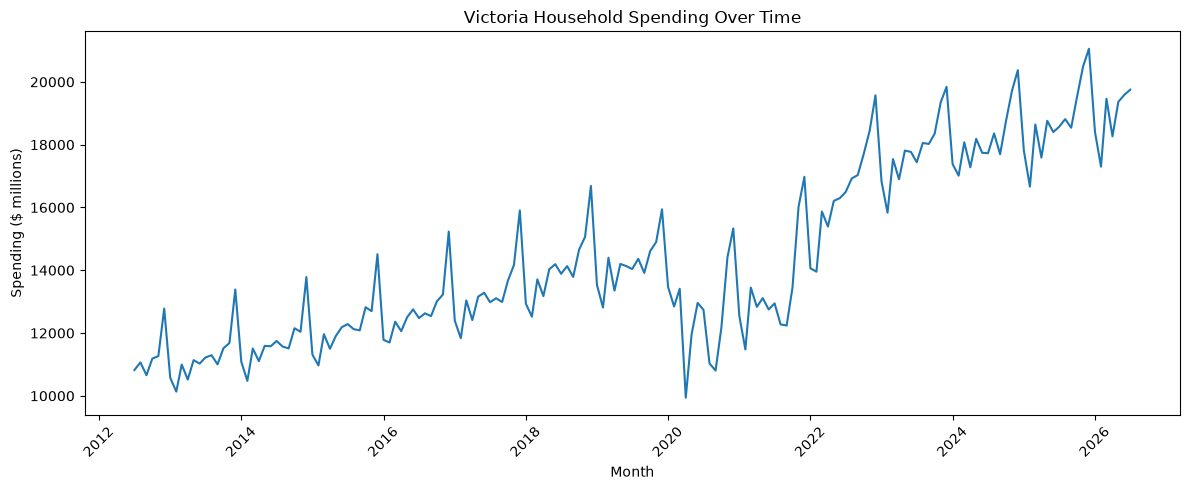

In [129]:
import matplotlib.pyplot as plt

vic_total = abs_spending[
    (abs_spending["geography"] == "Victoria") &
    (abs_spending["category"] == "Total (Household Spending Categories)")
]

plt.figure(figsize=(12, 5))

plt.plot(
    vic_total["month"],
    vic_total["spending_millions"]
)

plt.title("Victoria Household Spending Over Time")
plt.xlabel("Month")
plt.ylabel("Spending ($ millions)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretation:** Victoria household spending shows a long-term upward trend with recurring seasonal variation. The larger movements around 2020–2022 warrant contextual interpretation but do not appear to represent a structural data break.

### 9.2 Victoria vs Australia YoY Growth Validation

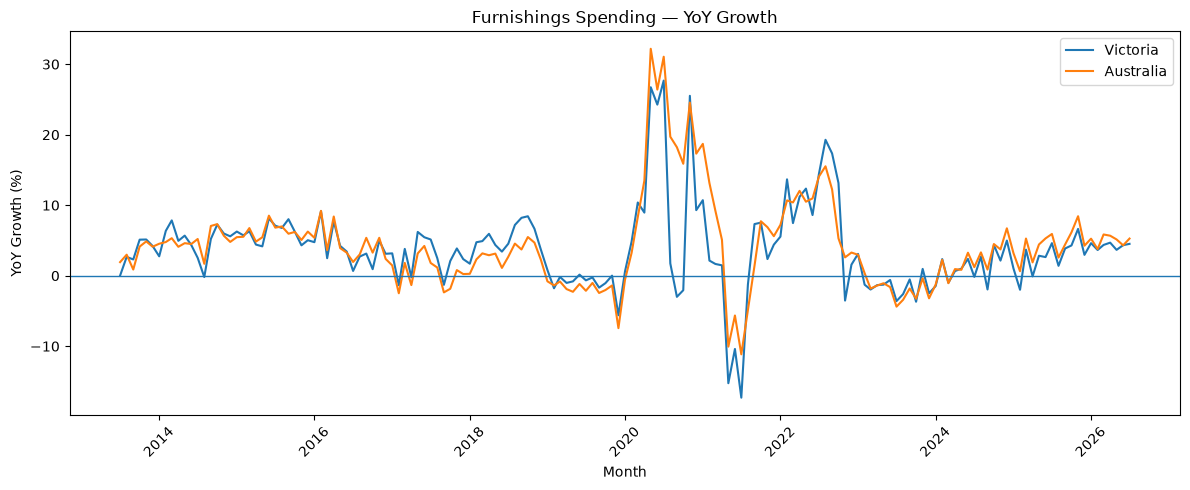

In [130]:
furnishings_compare = spending_comparison[
    spending_comparison["category"]
    == "Furnishings and household equipment"
]

plt.figure(figsize=(12, 5))

plt.plot(
    furnishings_compare["month"],
    furnishings_compare["vic_yoy_growth_pct"],
    label="Victoria"
)

plt.plot(
    furnishings_compare["month"],
    furnishings_compare["aus_yoy_growth_pct"],
    label="Australia"
)

plt.axhline(0, linewidth=1)

plt.title("Furnishings Spending — YoY Growth")
plt.xlabel("Month")
plt.ylabel("YoY Growth (%)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretation:** Victoria and Australia generally show similar movements in furnishings spending growth, supporting the benchmark comparison. Differences in magnitude are captured by the Victoria-versus-Australia growth gap.

### 9.3 Latest Category Growth Validation

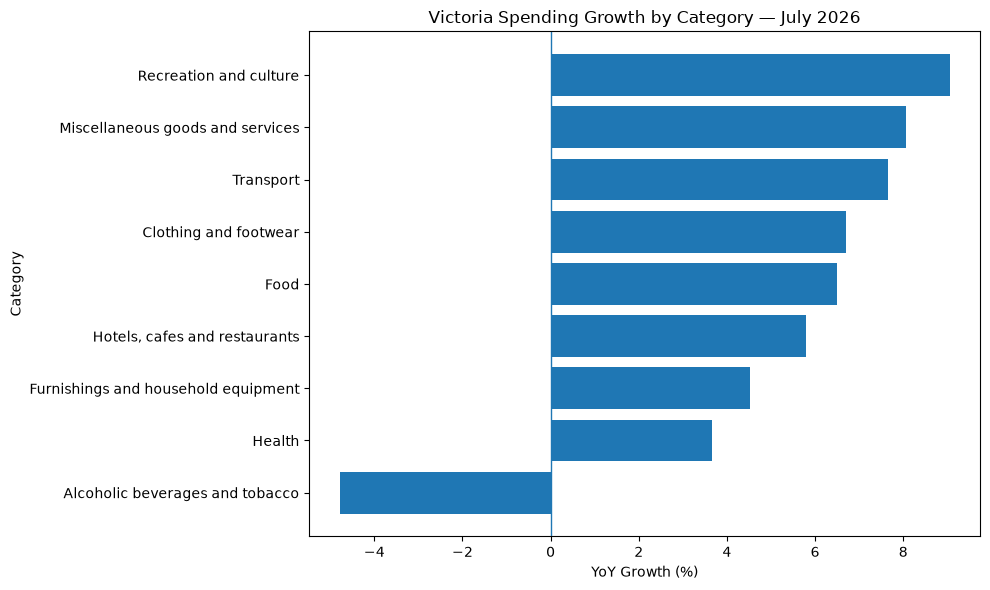

In [131]:
category_chart = (
    latest_spending
    .sort_values("vic_yoy_growth_pct")
)

plt.figure(figsize=(10, 6))

plt.barh(
    category_chart["category"],
    category_chart["vic_yoy_growth_pct"]
)

plt.axvline(0, linewidth=1)

plt.title("Victoria Spending Growth by Category — July 2026")
plt.xlabel("YoY Growth (%)")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

**Interpretation:** The visual ranking is consistent with the calculated July 2026 growth rankings. Recreation and culture records the strongest Victorian YoY growth, while alcoholic beverages and tobacco is the only category showing a clear decline.

### 9.4 Pedestrian Footfall Trend Validation

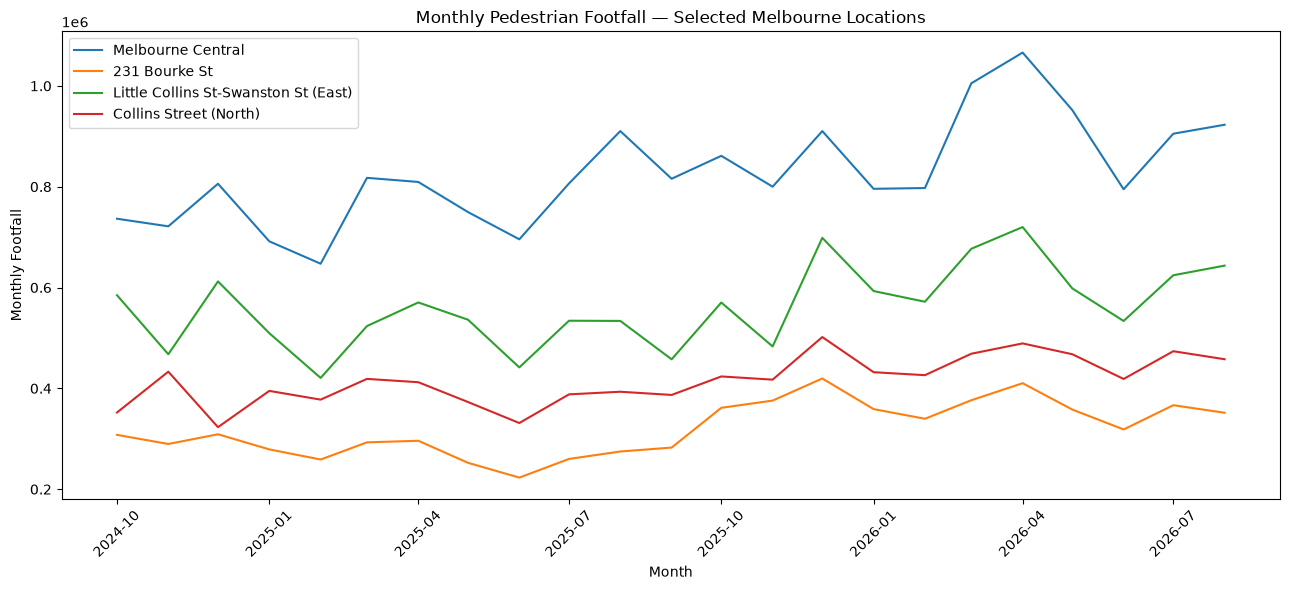

In [132]:
locations_to_plot = [
    "Melbourne Central",
    "231 Bourke St",
    "Little Collins St-Swanston St (East)",
    "Collins Street (North)"
]

plot_data = ped_analysis[
    ped_analysis["Sensor_Description"].isin(locations_to_plot)
]

plt.figure(figsize=(13, 6))

for location in locations_to_plot:

    temp = plot_data[
        plot_data["Sensor_Description"] == location
    ]

    plt.plot(
        temp["month"],
        temp["monthly_footfall"],
        label=location
    )

plt.title("Monthly Pedestrian Footfall — Selected Melbourne Locations")
plt.xlabel("Month")
plt.ylabel("Monthly Footfall")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretation:** Selected Melbourne locations show distinct traffic volumes while retaining plausible month-to-month patterns. No obvious unexplained discontinuities or prolonged flatlines are visible in these selected series.

### 9.5 Sensor Coverage Validation

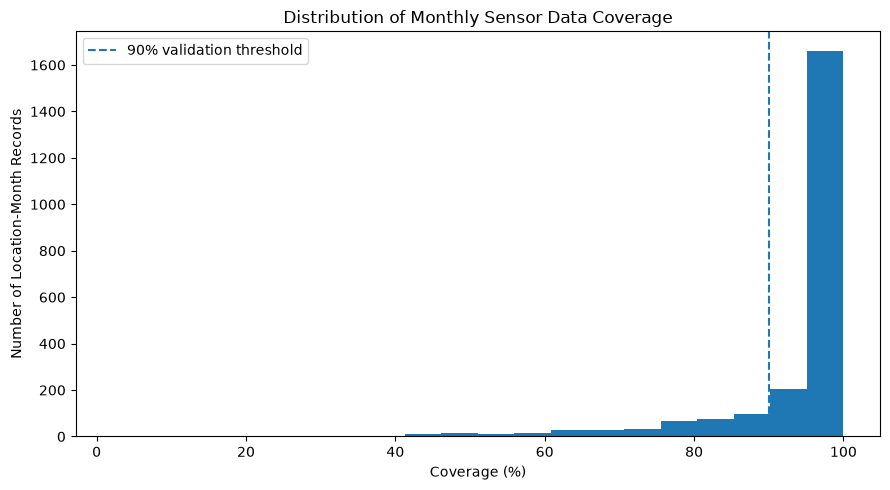

In [133]:
plt.figure(figsize=(9, 5))

plt.hist(
    ped_analysis["coverage_pct"],
    bins=20
)

plt.axvline(
    90,
    linestyle="--",
    label="90% validation threshold"
)

plt.title("Distribution of Monthly Sensor Data Coverage")
plt.xlabel("Coverage (%)")
plt.ylabel("Number of Location-Month Records")
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation:** Most location-month observations have high data coverage, with the majority clustered close to complete coverage. A smaller number fall below the 90% validation threshold, supporting the decision to exclude low-coverage months from reliable Year-on-Year comparisons.

### 9.6 Location Growth vs Footfall Scale

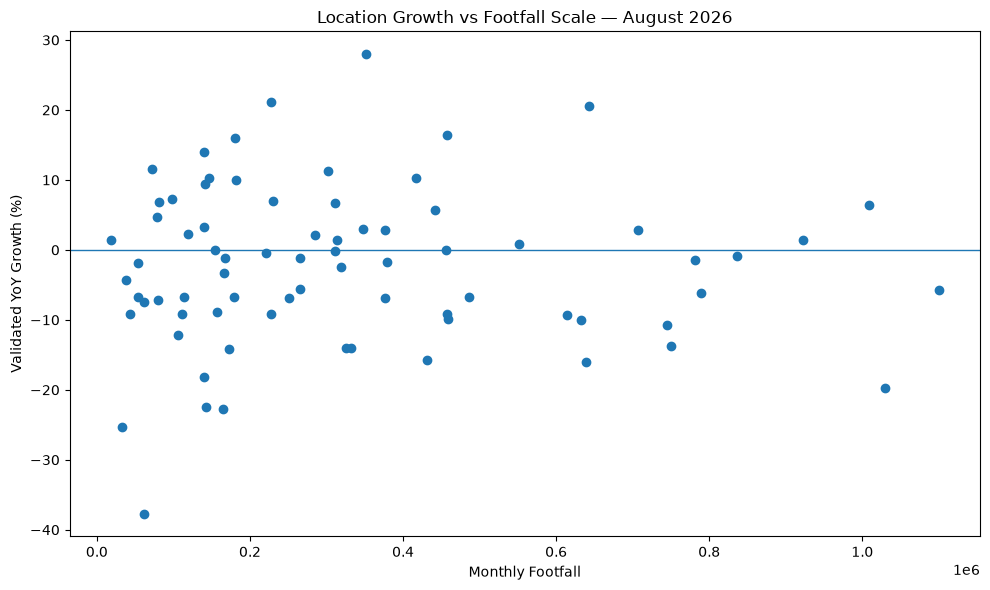

In [134]:
plt.figure(figsize=(10, 6))

plt.scatter(
    latest_locations["monthly_footfall"],
    latest_locations["validated_yoy_footfall_growth_pct"]
)

plt.axhline(
    0,
    linewidth=1
)

plt.title("Location Growth vs Footfall Scale — August 2026")
plt.xlabel("Monthly Footfall")
plt.ylabel("Validated YoY Growth (%)")
plt.tight_layout()
plt.show()

**Interpretation:** Locations vary substantially in both pedestrian scale and Year-on-Year growth. Some smaller locations show strong percentage growth, while higher-volume locations display a wider range of growth outcomes. Considering both growth and traffic volume therefore provides a more balanced location signal than using either measure alone.

## 10. Decision Intelligence — Market and Location Signals


**Reporting periods:** Market signals use the latest available ABS month, July 2026. Location signals use the latest complete pedestrian month, August 2026. These are treated as independent evidence streams rather than directly matched monthly observations.

In [135]:
def spending_signal(row):

    if (
        row["spending_trend_flag"] == "Strong Growth"
        and row["benchmark_flag"] != "Underperforming Australia"
    ):
        return "Strong Market Signal"

    elif row["spending_trend_flag"] in ["Strong Growth", "Moderate Growth"]:
        return "Positive Market Signal"

    elif row["spending_trend_flag"] == "Stable":
        return "Stable Market Signal"

    else:
        return "Weakening Market Signal"

Created a market signal by combining Victoria’s spending trend with its performance against the Australian benchmark. Strong growth that is at least in line with Australia is treated as the strongest signal, while weaker or declining categories receive lower signal labels. These market signals are kept separate from the pedestrian signals because the two datasets use different reporting periods.

In [136]:
latest_spending["spending_signal"] = (
    latest_spending.apply(
        spending_signal,
        axis=1
    )
)

Applied the market signal function to each category in the latest spending snapshot. This combines the trend and benchmark results into one simple business-facing signal for each category.

In [137]:
def location_signal(row):

    if (
        row["footfall_trend_flag"] == "Strong Growth"
        and row["footfall_volume_flag"] in [
            "Very High Footfall",
            "High Footfall"
        ]
    ):
        return "Strong Location Signal"

    elif row["footfall_trend_flag"] in [
        "Strong Growth",
        "Moderate Growth"
    ]:
        return "Positive Location Signal"

    elif row["footfall_trend_flag"] == "Stable":
        return "Stable Location Signal"

    else:
        return "Weakening Location Signal"

Created a location signal by combining validated footfall growth with current footfall volume. Locations with both strong growth and a high traffic base receive the strongest signal, while lower-growth or lower-volume locations receive more moderate signals.

In [138]:
latest_locations["location_signal"] = (
    latest_locations.apply(
        location_signal,
        axis=1
    )
)

Applied the location signal function to each location in the latest pedestrian snapshot. This combines the growth and volume results into one simple business-facing signal for each location.

## 11. Investigation Priority Framework


In [139]:
def market_priority(row):

    if row["spending_signal"] == "Strong Market Signal":
        return "High Priority"

    elif row["spending_signal"] == "Positive Market Signal":
        return "Medium Priority"

    elif row["spending_signal"] == "Stable Market Signal":
        return "Monitor"

    else:
        return "Low Priority"

Mapped the market signals into priority levels so the results are easier to use for further commercial investigation. Strong signals are treated as High Priority, positive signals as Medium Priority, stable signals as Monitor, and weakening signals as Low Priority.

In [140]:
latest_spending["market_priority"] = (
    latest_spending.apply(
        market_priority,
        axis=1
    )
)

Applied the market priority rules to each category in the latest spending snapshot. This converts the market signal into a clear investigation priority that can be used in the final decision-support output.

In [141]:
def location_priority(row):

    if row["location_signal"] == "Strong Location Signal":
        return "High Priority"

    elif row["location_signal"] == "Positive Location Signal":
        return "Medium Priority"

    elif row["location_signal"] == "Stable Location Signal":
        return "Monitor"

    else:
        return "Low Priority"

Mapped the location signals into priority levels so the results are easier to use for further commercial investigation. Strong location signals are treated as High Priority, positive signals as Medium Priority, stable signals as Monitor, and weakening signals as Low Priority.

In [142]:
latest_locations["location_priority"] = (
    latest_locations.apply(
        location_priority,
        axis=1
    )
)

Applied the location priority rules to each location in the latest pedestrian snapshot. This converts the location signal into a clear investigation priority for the final decision-support output.

In [143]:
latest_spending[
    [
        "category",
        "vic_yoy_growth_pct",
        "vic_vs_aus_yoy_gap",
        "vic_growth_rank",
        "spending_signal",
        "market_priority"
    ]
].sort_values(
    "vic_growth_rank"
)

,category,vic_yoy_growth_pct,vic_vs_aus_yoy_gap,vic_growth_rank,spending_signal,market_priority
1351,Recreation and culture,9.049828,-1.757171,1,Positive Market Signal,Medium Priority
1182,Miscellaneous goods and services,8.055309,-0.182553,2,Strong Market Signal,High Priority
1689,Transport,7.649538,-1.063669,3,Positive Market Signal,Medium Priority
337,Clothing and footwear,6.695887,0.244111,4,Strong Market Signal,High Priority
506,Food,6.503128,-0.034975,5,Strong Market Signal,High Priority
1013,"Hotels, cafes and restaurants",5.805358,-1.462374,6,Positive Market Signal,Medium Priority
675,Furnishings and household equipment,4.516349,-0.751623,7,Positive Market Signal,Medium Priority
844,Health,3.651966,-0.921602,8,Positive Market Signal,Medium Priority
168,Alcoholic beverages and tobacco,-4.786115,-8.529968,9,Weakening Market Signal,Low Priority


Reviewed the final market priorities by combining Victorian growth, performance against Australia, the market signal and the resulting investigation priority. This gives a clear shortlist of categories that may warrant further commercial investigation rather than relying on growth rate alone.

In [144]:
latest_locations[
    [
        "Sensor_Description",
        "monthly_footfall",
        "validated_yoy_footfall_growth_pct",
        "location_growth_rank",
        "footfall_volume_flag",
        "location_signal",
        "location_priority"
    ]
].sort_values(
    "location_growth_rank"
).head(25)

,Sensor_Description,monthly_footfall,validated_yoy_footfall_growth_pct,location_growth_rank,footfall_volume_flag,location_signal,location_priority
1134,231 Bourke St,351623,27.953640,1,Medium Footfall,Positive Location Signal,Medium Priority
1977,"Mounted on Toilet - Spencer Street, Batman Park",227928,21.155165,2,Medium Footfall,Positive Location Signal,Medium Priority
789,Little Collins St-Swanston St (East),643499,20.546967,3,High Footfall,Strong Location Signal,High Priority
973,Collins Street (North),457819,16.393872,4,High Footfall,Strong Location Signal,High Priority
904,Faraday St-Lygon St (West),180880,16.061804,5,Lower Footfall,Positive Location Signal,Medium Priority
1931,Awning of Nationwide Parking 474 Flinders Street,139615,13.936085,6,Lower Footfall,Positive Location Signal,Medium Priority
1451,Macaulay Rd (North),71472,11.572144,7,Lower Footfall,Positive Location Signal,Medium Priority
292,Collins Place (South),301666,11.277269,8,Medium Footfall,Positive Location Signal,Medium Priority
2023,iHub 489 Elizabeth Street,417526,10.311283,9,High Footfall,Strong Location Signal,High Priority
1365,Harbour Esplanade (West) - Pedestrian path,146071,10.211488,10,Lower Footfall,Positive Location Signal,Medium Priority


Reviewed the final location priorities by combining validated growth, current footfall scale, the location signal and the resulting investigation priority. This gives a more balanced shortlist of Melbourne locations that may warrant further commercial investigation rather than relying on growth alone.

## 12. Final Data Quality Check

In [145]:
print("Spending KPIs:")
print(abs_spending.isna().sum())

print("\nSpending comparison:")
print(spending_comparison.isna().sum())

print("\nLatest market priorities:")
print(latest_spending.isna().sum())

print("\nPedestrian KPIs:")
print(ped_analysis.isna().sum())

print("\nLatest location priorities:")
print(latest_locations.isna().sum())

Spending KPIs:
month                  0
geography              0
category               0
spending_millions      0
series_id              0
mom_growth_pct        24
yoy_growth_pct       288
spending_3m_avg       48
dtype: int64

Spending comparison:
month                      0
category                   0
vic_spending_millions      0
vic_mom_growth_pct        10
vic_yoy_growth_pct       120
vic_spending_3m_avg       20
aus_spending_millions      0
aus_mom_growth_pct        10
aus_yoy_growth_pct       120
aus_spending_3m_avg       20
vic_vs_aus_yoy_gap       120
dtype: int64

Latest market priorities:
month                    0
category                 0
vic_spending_millions    0
vic_mom_growth_pct       0
vic_yoy_growth_pct       0
vic_spending_3m_avg      0
aus_spending_millions    0
aus_mom_growth_pct       0
aus_yoy_growth_pct       0
aus_spending_3m_avg      0
vic_vs_aus_yoy_gap       0
vic_growth_rank          0
spending_trend_flag      0
benchmark_flag           0
spending_sign

This gives final checks, missing values across the final analytical tables and confirms whether they are expected or indicate a data quality issue.

Interpretation: Most nulls are expected because some KPIs require earlier months, prior year matches or sufficient sensor coverage before they can be calculated. Pedestrian YoY values are also left blank when the current or prior year month does not meet the 90% coverage rule. These values are kept as null rather than replaced with zero because zero would incorrectly suggest a valid calculation with no change.

The latest market priority and location priority tables contain no missing values.

## 13. Export Tableau-Ready Analytical Tables


In [146]:
spending_output_path = (
    "data\processed\spending_kpis.csv"
)

abs_spending.to_csv(
    spending_output_path,
    index=False
)

print("Saved:", spending_output_path)

Saved: C:\Study materials\retailpulse-ai\data\processed\spending_kpis.csv


Exported the full spending KPI history to the processed-data folder so it can be used directly in Tableau and reused in later analysis without recalculating the metrics.

In [147]:
comparison_output_path = (
    "data\processed\spending_comparison.csv"
)

spending_comparison.to_csv(
    comparison_output_path,
    index=False
)

print("Saved:", comparison_output_path)

Saved: C:\Study materials\retailpulse-ai\data\processed\spending_comparison.csv


Exported the Victoria-versus-Australia spending comparison table to the processed-data folder so the benchmark metrics can be used directly in Tableau and future analysis.

In [148]:
market_priority_output = (
    "data\processed\latest_market_priorities.csv"
)

latest_spending.to_csv(
    market_priority_output,
    index=False
)

print("Saved:", market_priority_output)

Saved: C:\Study materials\retailpulse-ai\data\processed\latest_market_priorities.csv


Exporting the latest market priority table to the processed data folder so the current category signals and priorities can be used directly in Tableau and the AI reporting layer.

In [149]:
pedestrian_kpi_output = (
    "data\processed\pedestrian_kpis.csv"
)

ped_analysis.to_csv(
    pedestrian_kpi_output,
    index=False
)

print("Saved:", pedestrian_kpi_output)

Saved: C:\Study materials\retailpulse-ai\data\processed\pedestrian_kpis.csv


Exported the full pedestrian KPI history to the processed data folder so the validated location metrics, coverage fields and historical trends can be reused in Tableau and later analysis.

In [150]:
location_priority_output = (
    "data\processed\latest_location_priorities.csv"
)

latest_locations.to_csv(
    location_priority_output,
    index=False
)

print("Saved:", location_priority_output)

Saved: C:\Study materials\retailpulse-ai\data\processed\latest_location_priorities.csv


Exported the latest location priority table to the processed data folder so the current location signals and investigation priorities can be used directly in Tableau and the AI reporting layer.

In [151]:
import os

files_to_check = [
    spending_output_path,
    comparison_output_path,
    market_priority_output,
    pedestrian_kpi_output,
    location_priority_output
]

for file in files_to_check:
    print(os.path.exists(file), file)

True C:\Study materials\retailpulse-ai\data\processed\spending_kpis.csv
True C:\Study materials\retailpulse-ai\data\processed\spending_comparison.csv
True C:\Study materials\retailpulse-ai\data\processed\latest_market_priorities.csv
True C:\Study materials\retailpulse-ai\data\processed\pedestrian_kpis.csv
True C:\Study materials\retailpulse-ai\data\processed\latest_location_priorities.csv


Checked that all five processed output files were successfully created before moving on to Tableau. All files returned True, confirming that the exports were saved correctly.

## 14. AI Reporting and Automation Layer

In [152]:
import pandas as pd

market_priorities = pd.read_csv(
    "data\processed\latest_market_priorities.csv"
)

location_priorities = pd.read_csv(
    "data\processed\latest_location_priorities.csv"
)

print("Market rows:", len(market_priorities))
print("Location rows:", len(location_priorities))

Market rows: 9
Location rows: 75


Loaded the final market priority and location priority tables into the AI reporting section. This ensures the AI layer works from the cleaned and validated decision support outputs rather than the raw data.

In [153]:
market_ai = market_priorities[
    [
        "category",
        "vic_yoy_growth_pct",
        "vic_vs_aus_yoy_gap",
        "spending_signal",
        "market_priority"
    ]
].copy()

location_ai = location_priorities[
    [
        "Sensor_Description",
        "monthly_footfall",
        "validated_yoy_footfall_growth_pct",
        "location_signal",
        "location_priority"
    ]
].copy()

display(market_ai)
display(location_ai.head(10))

,category,vic_yoy_growth_pct,vic_vs_aus_yoy_gap,spending_signal,market_priority
0,Alcoholic beverages and tobacco,-4.786115,-8.529968,Weakening Market Signal,Low Priority
1,Clothing and footwear,6.695887,0.244111,Strong Market Signal,High Priority
2,Food,6.503128,-0.034975,Strong Market Signal,High Priority
3,Furnishings and household equipment,4.516349,-0.751623,Positive Market Signal,Medium Priority
4,Health,3.651966,-0.921602,Positive Market Signal,Medium Priority
5,"Hotels, cafes and restaurants",5.805358,-1.462374,Positive Market Signal,Medium Priority
6,Miscellaneous goods and services,8.055309,-0.182553,Strong Market Signal,High Priority
7,Recreation and culture,9.049828,-1.757171,Positive Market Signal,Medium Priority
8,Transport,7.649538,-1.063669,Positive Market Signal,Medium Priority


,Sensor_Description,monthly_footfall,validated_yoy_footfall_growth_pct,location_signal,location_priority
0,Bourke Street Mall (North),638583,-16.074754,Weakening Location Signal,Low Priority
1,Bourke Street Mall (South),458341,-9.832547,Weakening Location Signal,Low Priority
2,Melbourne Central,922904,1.380923,Stable Location Signal,Monitor
3,Town Hall (West),1099700,-5.773545,Weakening Location Signal,Low Priority
4,Princes Bridge,789364,-6.146753,Weakening Location Signal,Low Priority
5,Flinders Underpass - Myki Barriers,265017,-5.639545,Weakening Location Signal,Low Priority
6,Southern Cross Station,379078,-1.785631,Stable Location Signal,Monitor
7,Victoria Point,61219,-7.480845,Weakening Location Signal,Low Priority
8,Docklands Waterfront City Building Side,81530,6.895150,Positive Location Signal,Medium Priority
9,Collins Place (South),301666,11.277269,Positive Location Signal,Medium Priority


Created smaller AI input tables containing only the validated metrics, signals and priorities needed for reporting. This keeps the AI summary focused on decision relevant information rather than unnecessary technical fields.

In [154]:
location_ai_priority = (
    location_ai[
        location_ai["location_priority"].isin(
            ["High Priority", "Medium Priority"]
        )
        & location_ai["validated_yoy_footfall_growth_pct"].notna()
        & location_ai["location_signal"].notna()
    ]
    .sort_values(
        "validated_yoy_footfall_growth_pct",
        ascending=False
    )
    .head(10)
    .copy()
)

display(location_ai_priority)

,Sensor_Description,monthly_footfall,validated_yoy_footfall_growth_pct,location_signal,location_priority
40,231 Bourke St,351623,27.953640,Positive Location Signal,Medium Priority
64,"Mounted on Toilet - Spencer Street, Batman Park",227928,21.155165,Positive Location Signal,Medium Priority
27,Little Collins St-Swanston St (East),643499,20.546967,Strong Location Signal,High Priority
33,Collins Street (North),457819,16.393872,Strong Location Signal,High Priority
30,Faraday St-Lygon St (West),180880,16.061804,Positive Location Signal,Medium Priority
63,Awning of Nationwide Parking 474 Flinders Street,139615,13.936085,Positive Location Signal,Medium Priority
52,Macaulay Rd (North),71472,11.572144,Positive Location Signal,Medium Priority
9,Collins Place (South),301666,11.277269,Positive Location Signal,Medium Priority
65,iHub 489 Elizabeth Street,417526,10.311283,Strong Location Signal,High Priority
49,Harbour Esplanade (West) - Pedestrian path,146071,10.211488,Positive Location Signal,Medium Priority


Filtered the location inputs to keep only High and Medium Priority locations with valid YoY growth and signal values, then selected the top 10 by validated growth. This keeps the AI prompt focused on the most relevant and complete location signals rather than passing the full location table.

In [155]:
market_ai_prompt = market_ai.copy()
location_ai_prompt = location_ai_priority.copy()

market_ai_prompt["vic_yoy_growth_pct"] = (
    market_ai_prompt["vic_yoy_growth_pct"].round(2)
)

market_ai_prompt["vic_vs_aus_yoy_gap"] = (
    market_ai_prompt["vic_vs_aus_yoy_gap"].round(2)
)

location_ai_prompt["validated_yoy_footfall_growth_pct"] = (
    location_ai_prompt["validated_yoy_footfall_growth_pct"].round(2)
)

market_text = market_ai_prompt.to_csv(index=False)
location_text = location_ai_prompt.to_csv(index=False)

ai_prompt = f"""
You are supporting a retail strategy manager.

Use only the validated data provided below.
Do not invent calculations, causal explanations, or recommendations beyond the evidence.
Do not claim that spending caused footfall or that footfall caused spending.
Do not recommend opening or closing a store.
Use the phrase "warrants further commercial investigation" when identifying notable opportunities.

MARKET DATA
{market_text}

LOCATION DATA
{location_text}

Create a concise management summary with:

1. Market signals
   - Highlight the strongest and weakest spending categories.
   - Mention Victoria's YoY growth and the gap versus Australia where relevant.

2. Location signals
   - Highlight the strongest priority locations.
   - Consider both validated YoY growth and monthly footfall scale.

3. Investigation priorities
   - Identify the categories and locations that warrant further commercial investigation.
   - Distinguish High Priority from Medium Priority.

4. Limitations
   - State that spending and pedestrian data are independent evidence streams.
   - Do not imply causality.
   - State that location signals are based on pedestrian activity, not store sales.

Keep the summary factual, concise, and suitable for a retail strategy manager.
Focus on the most decision-relevant signals rather than restating every row.
"""

print(ai_prompt)


You are supporting a retail strategy manager.

Use only the validated data provided below.
Do not invent calculations, causal explanations, or recommendations beyond the evidence.
Do not claim that spending caused footfall or that footfall caused spending.
Do not recommend opening or closing a store.
Use the phrase "warrants further commercial investigation" when identifying notable opportunities.

MARKET DATA
category,vic_yoy_growth_pct,vic_vs_aus_yoy_gap,spending_signal,market_priority
Alcoholic beverages and tobacco,-4.79,-8.53,Weakening Market Signal,Low Priority
Clothing and footwear,6.7,0.24,Strong Market Signal,High Priority
Food,6.5,-0.03,Strong Market Signal,High Priority
Furnishings and household equipment,4.52,-0.75,Positive Market Signal,Medium Priority
Health,3.65,-0.92,Positive Market Signal,Medium Priority
"Hotels, cafes and restaurants",5.81,-1.46,Positive Market Signal,Medium Priority
Miscellaneous goods and services,8.06,-0.18,Strong Market Signal,High Priority
Recre

Prepared a controlled AI prompt using only the validated market and location outputs. I rounded the metrics for readability and added clear guardrails so the AI could summarise the results without inventing calculations, implying causality or making unsupported store recommendations.

In [157]:
from openai import OpenAI, RateLimitError

client = OpenAI()

try:
    response = client.responses.create(
        model="gpt-5.6-luna",
        input=ai_prompt
    )

    ai_summary = response.output_text
    ai_source = "OpenAI API"

except RateLimitError:
    ai_summary = """
1. Market signals
Clothing and footwear, food, and miscellaneous goods and services are the strongest market signals, each classified as High Priority. Victoria recorded YoY growth of 6.70% for clothing and footwear, 6.50% for food, and 8.06% for miscellaneous goods and services. Clothing and footwear also recorded a small positive gap versus Australia of 0.24 percentage points. Alcoholic beverages and tobacco is the weakest category, with Victoria YoY spending down 4.79% and an 8.53 percentage point negative gap versus Australia.

2. Location signals
Little Collins St-Swanston St (East), Collins Street (North), and iHub 489 Elizabeth Street are the strongest High Priority location signals. Little Collins St-Swanston St (East) recorded 643,499 monthly pedestrian movements and 20.55% validated YoY growth. Collins Street (North) recorded 457,819 movements and 16.39% growth, while iHub 489 Elizabeth Street recorded 417,526 movements and 10.31% growth. Several Medium Priority locations also showed strong growth, including 231 Bourke St at 27.95%.

3. Investigation priorities
The High Priority market category group warrants further commercial investigation, including clothing and footwear, food, and miscellaneous goods and services.

The High Priority location group warrants further commercial investigation, including Little Collins St-Swanston St (East), Collins Street (North), and iHub 489 Elizabeth Street.

Medium Priority categories and locations may be considered as secondary areas for investigation.

4. Limitations
The spending and pedestrian datasets are independent evidence streams and should not be interpreted as causally related. Pedestrian signals measure activity around sensor locations and do not represent store sales, profitability, customer conversion, or site suitability on their own.
"""

    ai_source = "Demo fallback summary"

print("Summary source:", ai_source)
print()
print(ai_summary)

Summary source: Demo fallback summary


1. Market signals
Clothing and footwear, food, and miscellaneous goods and services are the strongest market signals, each classified as High Priority. Victoria recorded YoY growth of 6.70% for clothing and footwear, 6.50% for food, and 8.06% for miscellaneous goods and services. Clothing and footwear also recorded a small positive gap versus Australia of 0.24 percentage points. Alcoholic beverages and tobacco is the weakest category, with Victoria YoY spending down 4.79% and an 8.53 percentage point negative gap versus Australia.

2. Location signals
Little Collins St-Swanston St (East), Collins Street (North), and iHub 489 Elizabeth Street are the strongest High Priority location signals. Little Collins St-Swanston St (East) recorded 643,499 monthly pedestrian movements and 20.55% validated YoY growth. Collins Street (North) recorded 457,819 movements and 16.39% growth, while iHub 489 Elizabeth Street recorded 417,526 movements and 10.31% growt

Used the OpenAI API to generate a management summary from the validated market and location outputs. If the API is unavailable because of a rate-limit or credit issue, the workflow uses a clearly labelled fallback summary based on the same validated results. The AI is used only for reporting and does not calculate or replace the underlying analytical logic.

In [158]:
validation_checks = {
    "mentions_market_section": "Market signals" in ai_summary,
    "mentions_location_section": "Location signals" in ai_summary,
    "mentions_investigation_priorities": "Investigation priorities" in ai_summary,
    "mentions_limitations": "Limitations" in ai_summary,
    "uses_required_phrase": "warrants further commercial investigation" in ai_summary,
    "avoids_store_opening_recommendation": "open a store" not in ai_summary.lower(),
    "avoids_causal_language": "caused" not in ai_summary.lower(),
    "states_independent_evidence_streams": "independent evidence streams" in ai_summary.lower(),
    "states_pedestrian_not_store_sales": "do not represent store sales" in ai_summary.lower()
}

validation_checks

{'mentions_market_section': True,
 'mentions_location_section': True,
 'mentions_investigation_priorities': True,
 'mentions_limitations': True,
 'uses_required_phrase': True,
 'avoids_store_opening_recommendation': True,
 'avoids_causal_language': True,
 'states_independent_evidence_streams': True,
 'states_pedestrian_not_store_sales': True}

Validated the AI generated summary against the reporting guardrails to make sure it included the required sections and limitations, used the intended investigation wording, and avoided unsupported causal or store opening claims. All validation checks passed.

In [159]:
numeric_checks = {
    "clothing_yoy": "6.70%" in ai_summary,
    "food_yoy": "6.50%" in ai_summary,
    "misc_yoy": "8.06%" in ai_summary,
    "alcohol_yoy": "4.79%" in ai_summary,
    "little_collins_yoy": "20.55%" in ai_summary,
    "collins_street_yoy": "16.39%" in ai_summary,
    "ihub_yoy": "10.31%" in ai_summary,
    "bourke_231_yoy": "27.95%" in ai_summary
}

numeric_checks

{'clothing_yoy': True,
 'food_yoy': True,
 'misc_yoy': True,
 'alcohol_yoy': True,
 'little_collins_yoy': True,
 'collins_street_yoy': True,
 'ihub_yoy': True,
 'bourke_231_yoy': True}

Checked a selection of important market and location figures in the AI generated summary against the validated source metrics. All numerical checks passed, which gives me additional confidence that the AI did not alter or misstate the key values.

In [160]:
validation_results = {
    **validation_checks,
    **numeric_checks
}

validation_df = pd.DataFrame(
    validation_results.items(),
    columns=["check", "passed"]
)

display(validation_df)

print(
    "Validation passed:",
    validation_df["passed"].all()
)

,check,passed
0,mentions_market_section,True
1,mentions_location_section,True
2,mentions_investigation_priorities,True
3,mentions_limitations,True
4,uses_required_phrase,True
5,avoids_store_opening_recommendation,True
6,avoids_causal_language,True
7,states_independent_evidence_streams,True
8,states_pedestrian_not_store_sales,True
9,clothing_yoy,True


Validation passed: True


Combined the guardrail and numerical validation checks into one table and confirmed that every check passed. This gives me one clear audit result before using or exporting the AI generated summary.

In [161]:
from pathlib import Path

reports_dir = Path("reports")
reports_dir.mkdir(parents=True, exist_ok=True)

summary_path = reports_dir / "ai_management_summary.txt"
validation_path = reports_dir / "ai_validation_results.csv"

summary_path.write_text(
    f"Summary source: {ai_source}\n\n{ai_summary}",
    encoding="utf-8"
)

validation_df.to_csv(
    validation_path,
    index=False
)

print("Saved summary to:", summary_path)
print("Saved validation to:", validation_path)

Saved summary to: C:\Study materials\retailpulse-ai\reports\ai_management_summary.txt
Saved validation to: C:\Study materials\retailpulse-ai\reports\ai_validation_results.csv


Saved the AI generated management summary and the validation results into the project’s reports folder. This preserves both the reporting output and the evidence that the summary passed the validation checks.